# Import Library

In [123]:
# Import library yang akan digunakan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import kpss


# Import min-max scaling function
from sklearn.preprocessing import MinMaxScaler

# Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [65]:
# If Auto Arima is Error, you can use this step :
!pip install pmdarima

# Load Data

In [80]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [124]:
df1 = pd.read_csv('/content/drive/MyDrive/ML C Demo/Dataset Project1/store5.csv', index_col=0)
df1

,date,store_nbr,family,sales,onpromotion,dcoilwtico
id,,,,,,
1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1453,2013-01-01,5,BABY CARE,0.000,0,NaN
1454,2013-01-01,5,BEAUTY,0.000,0,NaN
1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...
3000586,2017-08-15,5,POULTRY,241.011,1,47.57
3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57


# EDA

In [125]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55572 entries, 1452 to 3000590
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         55572 non-null  object 
 1   store_nbr    55572 non-null  int64  
 2   family       55572 non-null  object 
 3   sales        55572 non-null  float64
 4   onpromotion  55572 non-null  int64  
 5   dcoilwtico   38379 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 3.0+ MB


## Define Target Variable

In [ ]:
# Businesses Understanding or Data Understanding

In [126]:
df1['date'] = pd.to_datetime(df1['date'])
df1 = df1.set_index('date')
df1

,store_nbr,family,sales,onpromotion,dcoilwtico
date,,,,,
2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
2013-01-01,5,BABY CARE,0.000,0,NaN
2013-01-01,5,BEAUTY,0.000,0,NaN
2013-01-01,5,BEVERAGES,0.000,0,NaN
2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...
2017-08-15,5,POULTRY,241.011,1,47.57
2017-08-15,5,PREPARED FOODS,52.121,0,47.57
2017-08-15,5,PRODUCE,1357.823,4,47.57


In [127]:
data = df1.groupby('date').agg({
    'sales': 'sum',
    'onpromotion': 'sum',
    'dcoilwtico':'mean'
}).reset_index()

data['dcoilwtico'] = (
    data['dcoilwtico']
    .ffill()
    .bfill()
)
data.head(20)

,date,sales,onpromotion,dcoilwtico
0,2013-01-01,0.000000,0,93.14
1,2013-01-02,10598.619020,0,93.14
2,2013-01-03,7770.968000,0,92.97
3,2013-01-04,7347.641991,0,93.12
4,2013-01-05,8192.598000,0,93.12
5,2013-01-06,10843.232030,0,93.12
6,2013-01-07,6468.321000,0,93.20
7,2013-01-08,6427.859000,0,93.21
8,2013-01-09,6057.108000,0,93.08
9,2013-01-10,5950.814020,0,93.81


In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1684 entries, 0 to 1683
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1684 non-null   datetime64[ns]
 1   sales        1684 non-null   float64       
 2   onpromotion  1684 non-null   int64         
 3   dcoilwtico   1684 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 52.8 KB


## Explore Each Variables

In [129]:
data.describe()


,date,sales,onpromotion,dcoilwtico
count,1684,1684.000000,1684.000000,1684.000000
mean,2015-04-24 08:27:04.703088128,9259.147608,88.699525,67.924899
min,2013-01-01 00:00:00,0.000000,0.000000,26.190000
25%,2014-02-26 18:00:00,7477.913750,0.000000,46.377500
50%,2015-04-24 12:00:00,9139.312500,36.000000,53.410000
75%,2016-06-19 06:00:00,10659.730495,161.250000,95.720000
max,2017-08-15 00:00:00,22555.506000,584.000000,110.620000
std,NaN,2517.773499,107.278570,25.676752


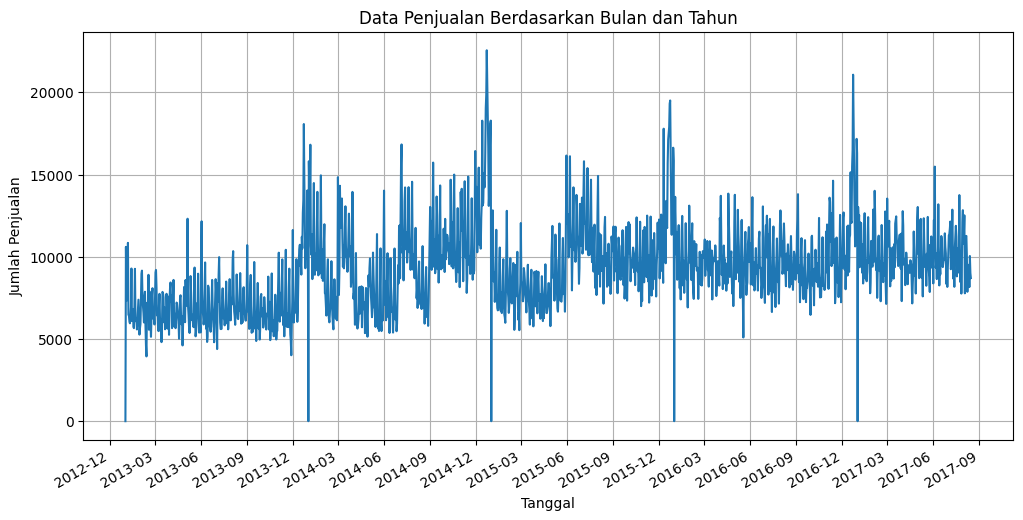

In [130]:
import matplotlib.dates as mdates

plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['sales'])
plt.title('Data Penjualan Berdasarkan Bulan dan Tahun')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Penjualan')
plt.grid(True)

# Format x-axis to show month and year
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # Show every 3 months
plt.gcf().autofmt_xdate() # Rotate and align the x-axis labels

plt.show()

# Data Preprocessing

## Checking Missing Values

In [131]:
data.isnull().sum()

,0
date,0
sales,0
onpromotion,0
dcoilwtico,0


## Handling Missing Values

## Stationarity Data

<Figure size 1500x500 with 0 Axes>

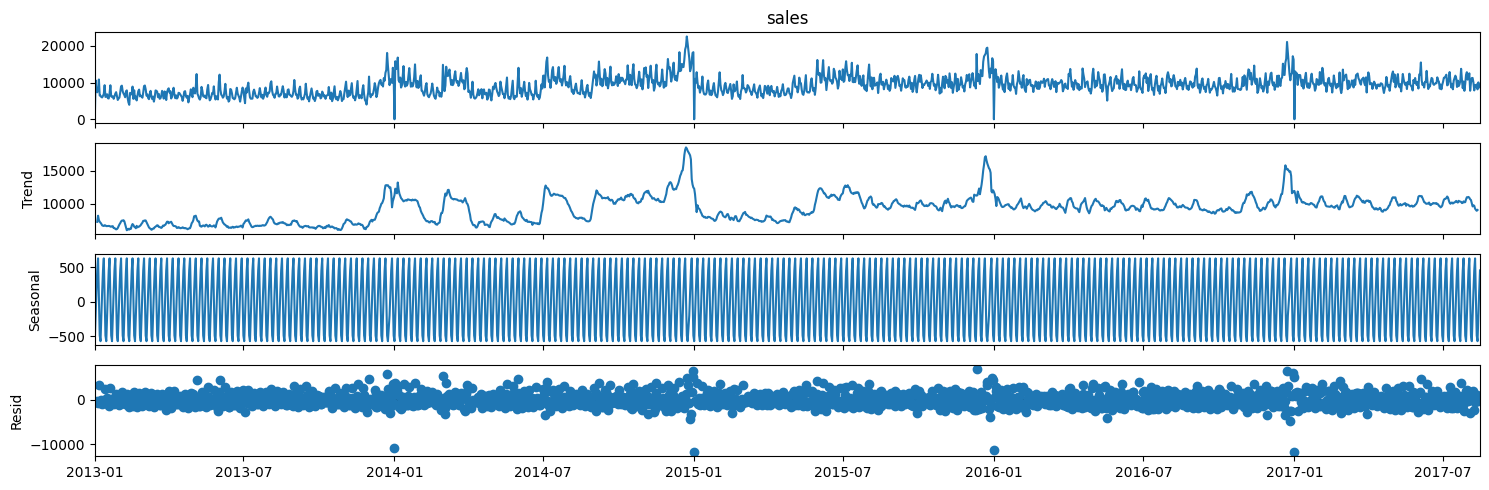

In [132]:
# Make fig size bigger
plt.rcParams['figure.figsize'] = (15, 5)
# Decompose time series
decomposition = seasonal_decompose(data.set_index('date')['sales'], model='add', period=7)
fig = plt.figure()
fig = decomposition.plot()

In [ ]:
# ADF Test
# If data is't stationer => Differencing

In [133]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(data['sales'].dropna())
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

ADF Statistic: -4.648021
p-value: 0.000105


In [134]:
result = kpss(
    data['sales'].dropna(),
    regression='c',  # constant
    nlags='auto'
)

print('KPSS Statistic:', result[0])
print('p-value:', result[1])
print('Lags Used:', result[2])
print('Critical Values:', result[3])

KPSS Statistic: 2.518892522562778
p-value: 0.01
Lags Used: 23
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_3558/363816620.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(


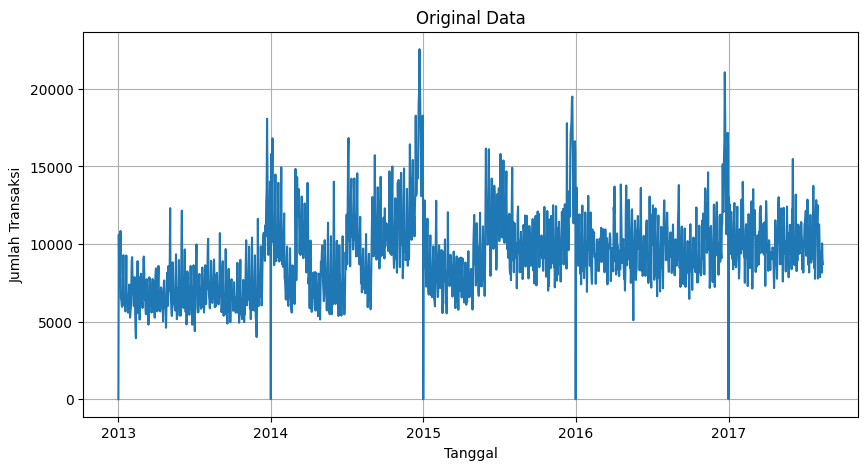

In [135]:
# Plot nilai original data
plt.figure(figsize=(10, 5))
plt.plot(data.set_index('date')['sales'].dropna())
plt.title('Original Data')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Transaksi')
plt.grid(True)
plt.show()

Nilai p-value kurang dari 0.05, yang berarti data adalah stasioner, kita bisa menggunakan nilai I = 0

## Differencing ke-1 atau i = 1

In [136]:
from statsmodels.tsa.stattools import adfuller
from numpy import log
result = adfuller(data['sales'].diff().dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -10.476482116962782
p-value: 1.2452157961888015e-18


In [137]:
result = kpss(
    data['sales'].diff().dropna(),
    regression='c',  # constant
    nlags='auto'
)

print('KPSS Statistic:', result[0])
print('p-value:', result[1])
print('Lags Used:', result[2])
print('Critical Values:', result[3])

KPSS Statistic: 0.09855939584622449
p-value: 0.1
Lags Used: 64
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


/tmp/ipykernel_3558/4189609903.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(


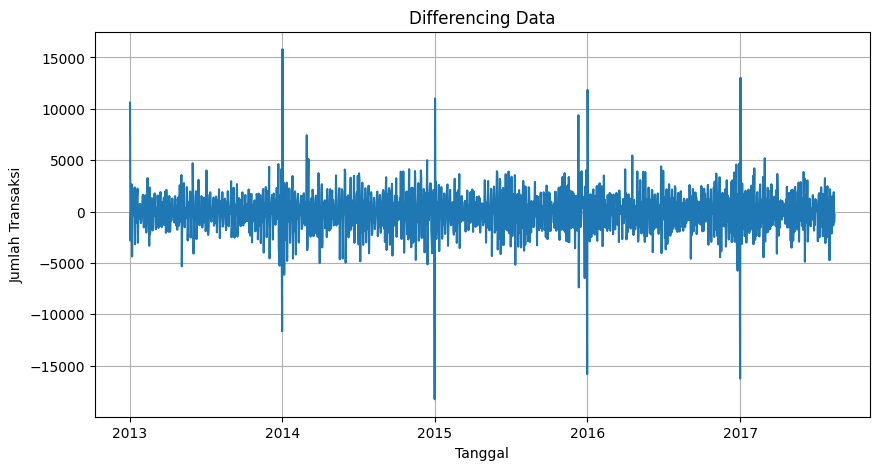

In [138]:
# Plot nilai differencing data
plt.figure(figsize=(10, 5))
plt.plot(data.set_index('date')['sales'].diff().dropna())
plt.title('Differencing Data')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Transaksi')
plt.grid(True)
plt.show()

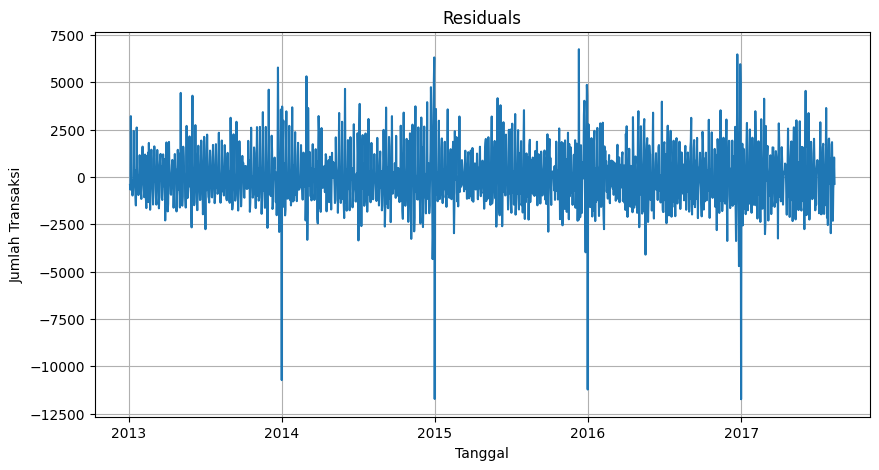

In [139]:
residuals = decomposition.resid.dropna()
plt.figure(figsize=(10, 5))
plt.plot(residuals)
plt.title('Residuals')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Transaksi')
plt.grid(True)
plt.show()

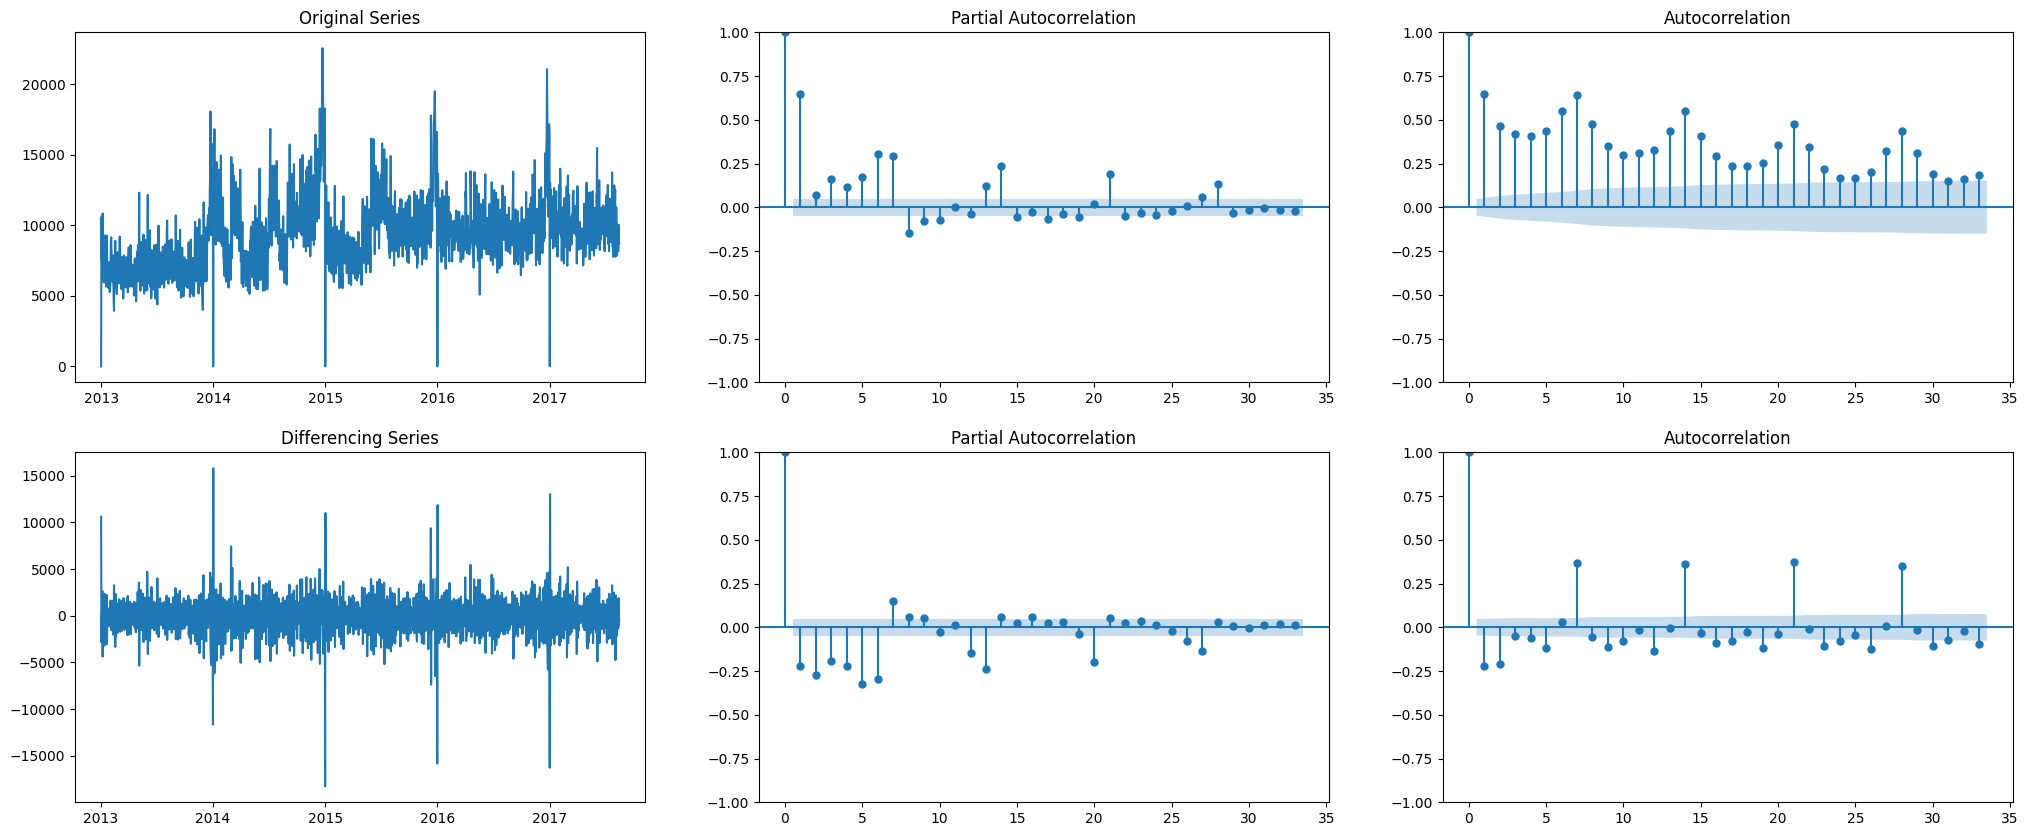

In [140]:
# Plot ACF dan PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
fig, ax = plt.subplots(2, 3, figsize=(25, 10))

ax[0, 0].set_title('Original Series')
ax[0, 0].plot(data.set_index('date')['sales'])
ax[0, 1] = plot_pacf(data['sales'], ax=ax[0, 1])
ax[0, 2] = plot_acf(data['sales'], ax=ax[0, 2])

ax[1, 0].set_title('Differencing Series')
ax[1, 0].plot(data.set_index('date')['sales'].diff().dropna())
ax[1, 1] = plot_pacf(data['sales'].diff().dropna(), ax=ax[1, 1])
ax[1, 2] = plot_acf(data['sales'].diff().dropna(), ax=ax[1, 2])

Dari PACF, kita bisa mengambilkan nilai AR(p) = 9,<br>
Dari ACF, kita bisa mengambilkan nilai MA(q) = 5,<br>
Dari hasil uji diagnostik, kita bisa mengambilkan nilai d = 1, <br>
Dari PACF, kita bisa mengambil kesimpulan seasonal = 7  

## Correlation (Optional : If Using Exogenous Variable)

In [141]:
data[['sales','onpromotion']].corr()

,sales,onpromotion
sales,1.000000,0.321797
onpromotion,0.321797,1.000000


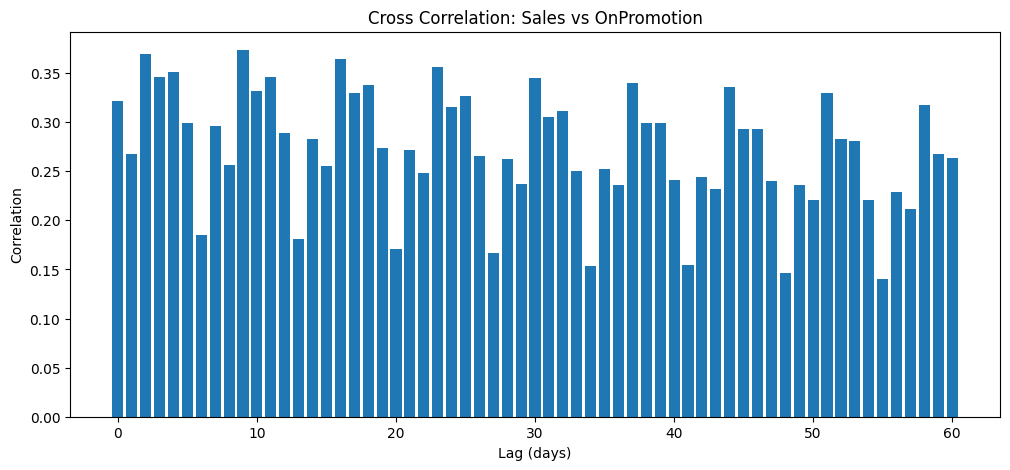

lag            9.000000
correlation    0.373389
Name: 9, dtype: float64


In [142]:
max_lag = 60

corrs = []

for lag in range(max_lag + 1):
    corr = data['sales'].corr(
        data['onpromotion'].shift(lag)
    )
    corrs.append(corr)

ccf_df = pd.DataFrame({
    'lag': range(max_lag + 1),
    'correlation': corrs
})

plt.figure(figsize=(12,5))
plt.bar(ccf_df['lag'], ccf_df['correlation'])

plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.title('Cross Correlation: Sales vs OnPromotion')

plt.show()

best_lag = ccf_df.loc[
    ccf_df['correlation'].abs().idxmax()
]

print(best_lag)

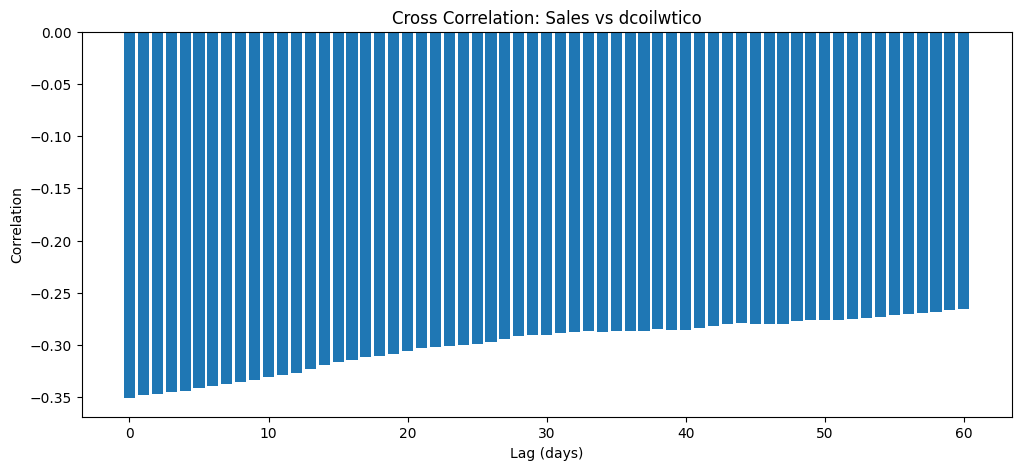

lag            0.000000
correlation   -0.351082
Name: 0, dtype: float64


In [143]:
max_lag = 60

corrs = []

for lag in range(max_lag + 1):
    corr = data['sales'].corr(
        data['dcoilwtico'].shift(lag)
    )
    corrs.append(corr)

ccf_df = pd.DataFrame({
    'lag': range(max_lag + 1),
    'correlation': corrs
})

plt.figure(figsize=(12,5))
plt.bar(ccf_df['lag'], ccf_df['correlation'])

plt.xlabel('Lag (days)')
plt.ylabel('Correlation')
plt.title('Cross Correlation: Sales vs dcoilwtico')

plt.show()

best_lag = ccf_df.loc[
    ccf_df['correlation'].abs().idxmax()
]

print(best_lag)

### Correlation of Sales with Moving Averages (1-60 days)

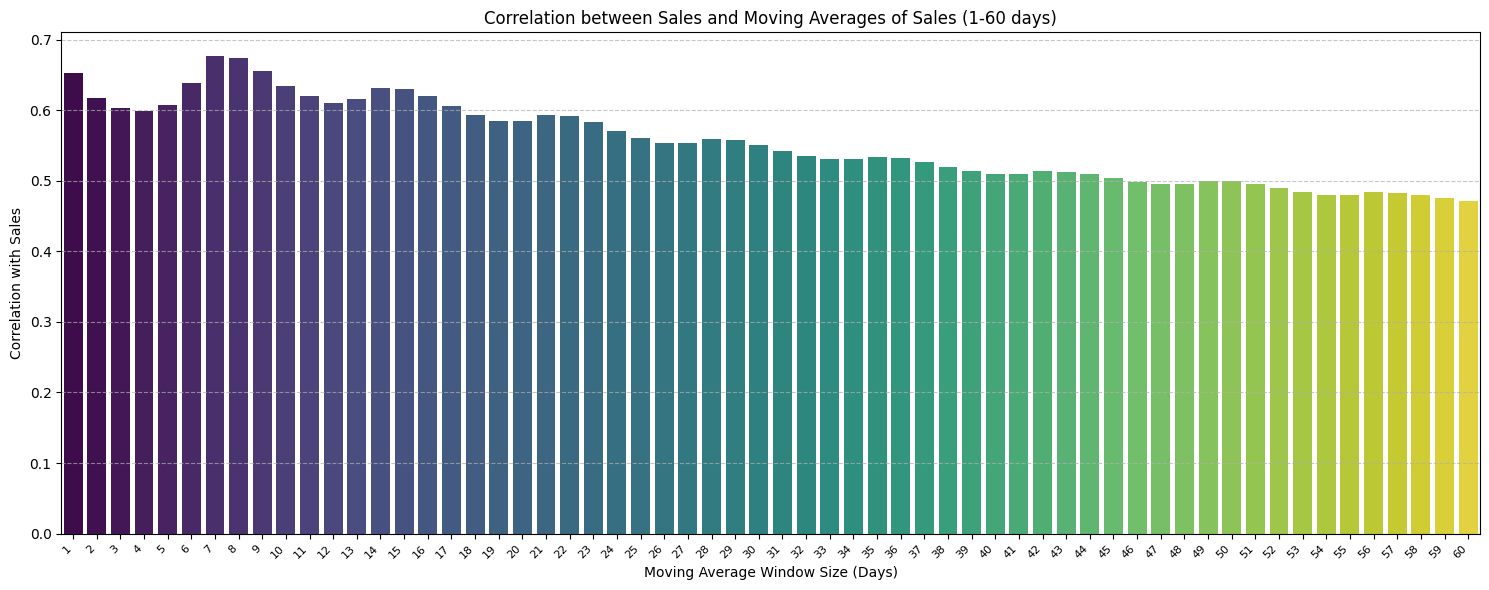

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

max_window_size = 60
correlations_sales_ma = []

for window in range(1, max_window_size + 1):
    # Calculate moving average of 'sales' for the current window size
    sales_ma = data['sales'].shift(1).rolling(window=window).mean()

    # Combine sales and the calculated moving average, dropping NaNs
    temp_df = pd.DataFrame({'sales': data['sales'], 'sales_ma': sales_ma}).dropna()

    # Calculate correlation
    if not temp_df.empty:
        correlation = temp_df['sales'].corr(temp_df['sales_ma'])
        correlations_sales_ma.append({'window_size': window, 'correlation': correlation})
    else:
        correlations_sales_ma.append({'window_size': window, 'correlation': None}) # Handle cases with no data

# Convert to DataFrame for easy plotting
correlations_sales_df = pd.DataFrame(correlations_sales_ma).dropna()

plt.figure(figsize=(15, 6))
sns.barplot(x='window_size', y='correlation', hue='window_size', data=correlations_sales_df, palette='viridis', legend=False)
plt.title('Correlation between Sales and Moving Averages of Sales (1-60 days)')
plt.xlabel('Moving Average Window Size (Days)')
plt.ylabel('Correlation with Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

## Feature Engineering / New Features (Optional : If Using Exogenous Variable)

In [145]:
# kita membuat lag 9 untuk onpromotion dan hapus 9 data pertama
data['onpromotion_lag9'] = data['onpromotion'].shift(9)

# Sales 7 hari sebelumnya
data['sales_lag7'] = data['sales'].shift(7)

# Moving Average 7 hari sebelumnya
data['sales_ma7'] = (
    data['sales']
    .shift(1)          # hindari data leakage
    .rolling(window=7)
    .mean()
)

data = data.dropna().reset_index(drop=True)
data

,date,sales,onpromotion,dcoilwtico,onpromotion_lag9,sales_lag7,sales_ma7
0,2013-01-10,5950.81402,0,93.81,0.0,7770.968000,7586.818289
1,2013-01-11,6379.97300,0,93.60,0.0,7347.641991,7326.796292
2,2013-01-12,6935.20600,0,93.60,0.0,8192.598000,7188.557864
3,2013-01-13,9284.70298,0,93.60,0.0,10843.232030,7008.930436
4,2013-01-14,6090.49100,0,94.27,0.0,6468.321000,6786.283429
...,...,...,...,...,...,...,...
1670,2017-08-11,9510.87100,263,48.81,322.0,9944.972000,9792.568999
1671,2017-08-12,8157.07000,116,48.81,104.0,11221.937000,9730.554570
1672,2017-08-13,10044.82100,124,48.81,260.0,11264.564000,9292.716427
1673,2017-08-14,9011.57490,118,47.59,129.0,10011.661000,9118.467427


In [146]:
print(
    data[['sales','onpromotion','onpromotion_lag9','dcoilwtico','sales_lag7', 'sales_ma7']]
    .corr()['sales']
    .sort_values(ascending=False)
)

sales               1.000000
sales_ma7           0.676290
sales_lag7          0.643219
onpromotion_lag9    0.373389
onpromotion         0.320390
dcoilwtico         -0.349437
Name: sales, dtype: float64


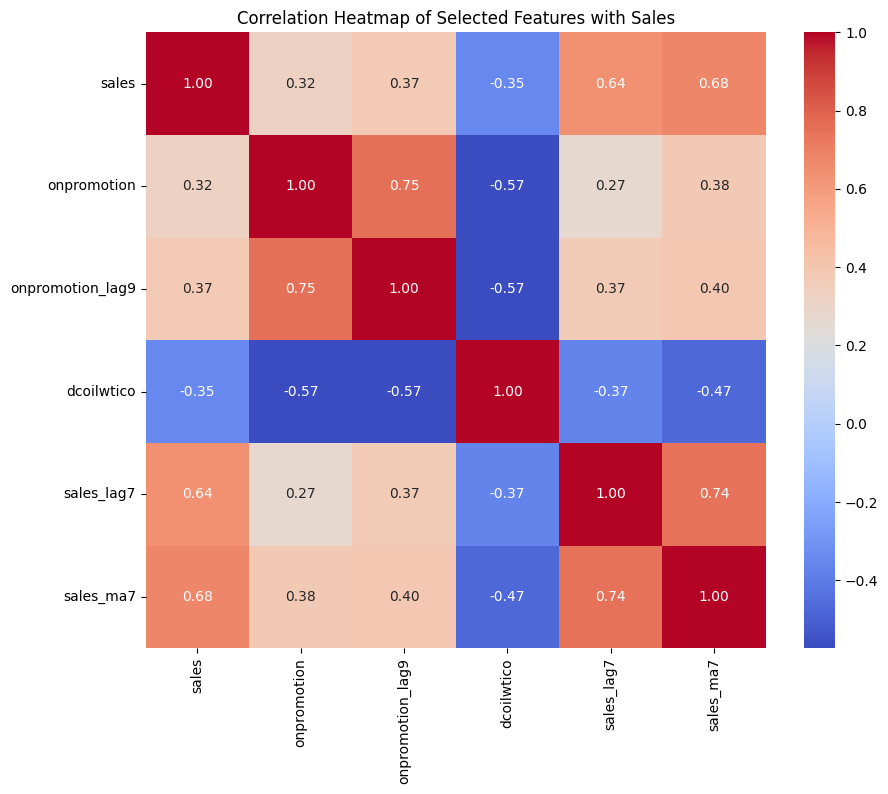

sales               1.000000
sales_ma7           0.676290
sales_lag7          0.643219
onpromotion_lag9    0.373389
onpromotion         0.320390
dcoilwtico         -0.349437
Name: sales, dtype: float64


In [147]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    data[['sales','onpromotion','onpromotion_lag9','dcoilwtico','sales_lag7', 'sales_ma7']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title('Correlation Heatmap of Selected Features with Sales')
plt.show()

print(
    data[['sales','onpromotion','onpromotion_lag9','dcoilwtico','sales_lag7', 'sales_ma7']]
    .corr()['sales']
    .sort_values(ascending=False)
)


## Feature Selection (Optional : If Using Exogenous Variable)

# Train Test Split

In [148]:
#  Train 80% Test 20%
train = data[:len(data)-335]
test = data[len(data)-335:]
#print(train.shape)
#print(test.shape)

#split_idx = int(len(data) * 0.8)

#train = data.iloc[:split_idx]
#test = data.iloc[split_idx:]
#1340
#335

print("Jumlah train:", len(train))
print("Jumlah test :", len(test))

Jumlah train: 1340
Jumlah test : 335


In [106]:
print(test[test['sales'] == 0])

           date  sales  onpromotion  dcoilwtico  onpromotion_lag9  sales_lag7  \
1448 2017-01-01    0.0            0       53.75             322.0   18118.149   

         sales_ma7  
1448  14200.402719  


# Modelling

## ARIMA / SARIMA

In [ ]:
# Sales Data Only
# p,d,q = (9,1,5)

##ARIMA

In [149]:
arima = ARIMA(train['sales'],order=(9,1,5))
arima_fit = arima.fit()
pred_arima = arima_fit.forecast(steps=len(test['sales']))
wape_arima = (np.sum(np.abs(test['sales'] - pred_arima))/ np.sum(np.abs(test['sales']))) * 100
mae_arima = mean_absolute_error(test['sales'],pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test['sales'],pred_arima))

print("ARIMA WAPE:", wape_arima)
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA AIC:", arima_fit.aic)
print("ARIMA BIC:", arima_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA WAPE: 12.438332398148887
ARIMA MAE: 1259.8065547333479
ARIMA RMSE: 1892.178096554718
ARIMA AIC: 23517.608772400705
ARIMA BIC: 23595.60394758607


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [150]:
arima = ARIMA(train['sales'],order=(1,0,5))
arima_fit = arima.fit()
pred_arima = arima_fit.forecast(steps=len(test['sales']))
wape_arima = (np.sum(np.abs(test['sales'] - pred_arima))/ np.sum(np.abs(test['sales']))) * 100
mae_arima = mean_absolute_error(test['sales'],pred_arima)
rmse_arima = np.sqrt(mean_squared_error(test['sales'],pred_arima))

print("ARIMA WAPE:", wape_arima)
print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA AIC:", arima_fit.aic)
print("ARIMA BIC:", arima_fit.bic)

ARIMA WAPE: 15.32340705374184
ARIMA MAE: 1552.0190351259753
ARIMA RMSE: 2218.3581495738067
ARIMA AIC: 23850.15998694617
ARIMA BIC: 23891.76338608973


## ARIMAX / SARIMAX (with exogenous variable)

## SARIMA

In [151]:
sarima = SARIMAX(train['sales'],order=(9,1,5),seasonal_order=(0,0,0,7))
sarima_fit = sarima.fit()
pred_sarima = sarima_fit.forecast(steps=len(test['sales']))

#evaluasi
wape_sarima = (np.sum(np.abs(test['sales'] - pred_sarima))/ np.sum(np.abs(test['sales']))) * 100
mae_sarima = mean_absolute_error(test['sales'],pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test['sales'],pred_sarima))
mse_sarima = mean_squared_error(test['sales'],pred_sarima)

print("SARIMA WAPE:", wape_sarima)
print("SARIMA MAE:", mae_sarima)
print("SARIMA MSE:", mse_sarima)
print("SARIMA RMSE:", rmse_sarima)
print("SARIMA AIC:", sarima_fit.aic)
print("SARIMA BIC:", sarima_fit.bic)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA WAPE: 12.438332398148887
SARIMA MAE: 1259.8065547333479
SARIMA MSE: 3580337.9490814353
SARIMA RMSE: 1892.178096554718
SARIMA AIC: 23517.608772400705
SARIMA BIC: 23595.60394758607


##SARIMAX

In [153]:
model = SARIMAX(
    train['sales'],
    exog=train[['onpromotion', 'dcoilwtico','sales_ma7']],
    order=(9,1,5),
    seasonal_order=(0,0,0,0) # Changed P from 9 to 0 to avoid overlapping autoregressive lags
)
sarimax_fit = model.fit()
forecast = sarimax_fit.forecast(steps=len(test),exog=test[['onpromotion', 'dcoilwtico','sales_ma7']])
wape_sarimax = (np.sum(np.abs(test['sales'] - forecast))/ np.sum(np.abs(test['sales']))) * 100
mae_sarimax = mean_absolute_error(test['sales'],forecast)
rmse_sarimax = np.sqrt(mean_squared_error(test['sales'],forecast))

print("SARIMAX WAPE:", wape_sarimax)
print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", sarimax_fit.aic)
print("SARIMAX BIC:", sarimax_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX WAPE: 12.678806674526507
SARIMAX MAE: 1284.1627996002542
SARIMAX RMSE: 1724.5377883526494
SARIMAX AIC: 23413.48411862456
SARIMAX BIC: 23460.287942661067


In [154]:
model = SARIMAX(
    train['sales'],
    exog=train[['onpromotion', 'dcoilwtico','sales_ma7']],
    order=(9,1,5),
    seasonal_order=(0,0,1,7) # Changed P from 9 to 0 to avoid overlapping autoregressive lags
)
sarimax_fit = model.fit()
forecast = sarimax_fit.forecast(steps=len(test),exog=test[['onpromotion', 'dcoilwtico','sales_ma7']])
wape_sarimax = (np.sum(np.abs(test['sales'] - forecast))/ np.sum(np.abs(test['sales']))) * 100
mae_sarimax = mean_absolute_error(test['sales'],forecast)
rmse_sarimax = np.sqrt(mean_squared_error(test['sales'],forecast))

print("SARIMAX WAPE:", wape_sarimax)
print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", sarimax_fit.aic)
print("SARIMAX BIC:", sarimax_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX WAPE: 12.176360602626083
SARIMAX MAE: 1233.2729508232283
SARIMAX RMSE: 1778.0162741050449
SARIMAX AIC: 23348.846247735764
SARIMAX BIC: 23447.640136303897


In [155]:
model = SARIMAX(
    train['sales'],
    exog=train[['onpromotion_lag9', 'dcoilwtico','sales_ma7']],
    order=(9,1,5),
    seasonal_order=(0,0,0,0) # Changed P from 9 to 0 to avoid overlapping autoregressive lags
)
sarimax_fit = model.fit()
forecast = sarimax_fit.forecast(steps=len(test),exog=test[['onpromotion_lag9', 'dcoilwtico','sales_ma7']])
wape_sarimax = (np.sum(np.abs(test['sales'] - forecast))/ np.sum(np.abs(test['sales']))) * 100
mae_sarimax = mean_absolute_error(test['sales'],forecast)
rmse_sarimax = np.sqrt(mean_squared_error(test['sales'],forecast))

print("SARIMAX WAPE:", wape_sarimax)
print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", sarimax_fit.aic)
print("SARIMAX BIC:", sarimax_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


SARIMAX WAPE: 12.49489521483804
SARIMAX MAE: 1265.535474409894
SARIMAX RMSE: 1899.8922562503399
SARIMAX AIC: 23434.437910577246
SARIMAX BIC: 23528.032120799686


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [157]:
model = SARIMAX(
    train['sales'],
    exog=train[['onpromotion_lag9', 'dcoilwtico','sales_ma7',]],
    order=(9,1,5),
    seasonal_order=(0,0,1,7)
)
sarimax_fit_s = model.fit()
forecast = sarimax_fit.forecast(steps=len(test),exog=test[['onpromotion_lag9','dcoilwtico','sales_ma7',]])
wape_sarimax = (np.sum(np.abs(test['sales'] - forecast))/ np.sum(np.abs(test['sales']))) * 100
mae_sarimax = mean_absolute_error(test['sales'],forecast)
mse_sarimax = mean_squared_error(test['sales'],forecast)
rmse_sarimax = np.sqrt(mean_squared_error(test['sales'],forecast))

print("SARIMAX WAPE:", wape_sarimax)
print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX MSE:", mse_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", sarimax_fit.aic)
print("SARIMAX BIC:", sarimax_fit.bic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX WAPE: 11.75880541572819
SARIMAX MAE: 1190.9812074786655
SARIMAX MSE: 3119673.5280039865
SARIMAX RMSE: 1766.2597566620789
SARIMAX AIC: 23394.728819060518
SARIMAX BIC: 23493.52270762865


In [116]:
model = SARIMAX(
    train['sales'],
    exog=train[['onpromotion', 'dcoilwtico','sales_ma7',]],
    order=(1,0,2),
    seasonal_order=(1,0,1,7)
)
sarimax_fit = model.fit()
forecast = sarimax_fit.forecast(steps=len(test),exog=test[['onpromotion','dcoilwtico','sales_ma7',]])
wape_sarimax = (np.sum(np.abs(test['sales'] - forecast))/ np.sum(np.abs(test['sales']))) * 100
mae_sarimax = mean_absolute_error(test['sales'],forecast)
mse_sarimax = mean_squared_error(test['sales'],forecast)
rmse_sarimax = np.sqrt(mean_squared_error(test['sales'],forecast))

print("SARIMAX WAPE:", wape_sarimax)
print("SARIMAX MAE:", mae_sarimax)
print("SARIMAX MSE:", mse_sarimax)
print("SARIMAX RMSE:", rmse_sarimax)
print("SARIMAX AIC:", sarimax_fit.aic)
print("SARIMAX BIC:", sarimax_fit.bic)

SARIMAX WAPE: 12.678806674526507
SARIMAX MAE: 1284.1627996002542
SARIMAX MSE: 2974030.5834562476
SARIMAX RMSE: 1724.5377883526494
SARIMAX AIC: 23413.48411862456
SARIMAX BIC: 23460.287942661067


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


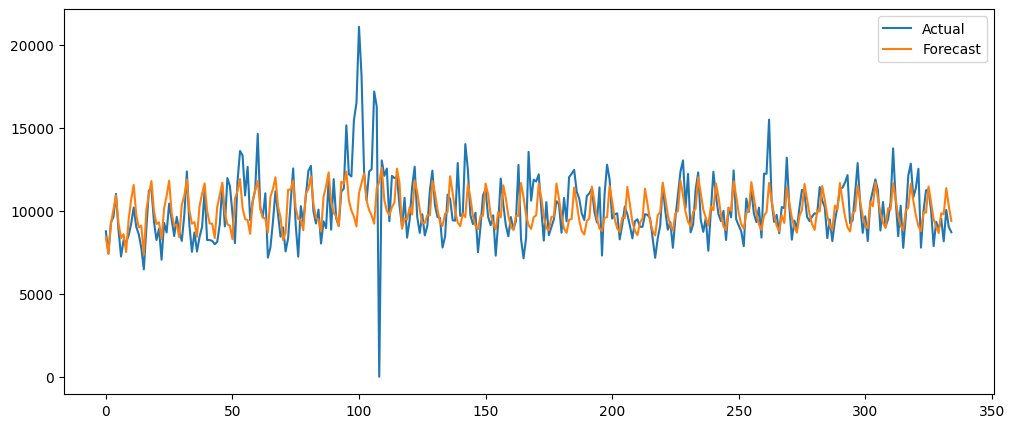

In [158]:
plt.figure(figsize=(12,5))
plt.plot(test['sales'].values, label='Actual')
plt.plot(forecast.values, label='Forecast')
plt.legend()
plt.show()

In [159]:
print(sarimax_fit_s.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               sales   No. Observations:                 1340
Model:             SARIMAX(9, 1, 5)x(0, 0, [1], 7)   Log Likelihood              -11678.364
Date:                             Thu, 04 Jun 2026   AIC                          23394.729
Time:                                     01:28:49   BIC                          23493.523
Sample:                                          0   HQIC                         23431.742
                                            - 1340                                         
Covariance Type:                               opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
onpromotion_lag9     5.1010      1.219      4.184      0.000       2.712       7.491
dcoilwtic

### Auto ARIMA

In [112]:
import pmdarima as pm
model = pm.auto_arima(train['sales'], # Pass only the 'sales' column as the endogenous variable
                      exog=train[['onpromotion', 'dcoilwtico', 'sales_ma7']], # Pass exogenous variables
                      start_p=0,        # nilai p pertama
                      start_q=0,        # nilai q pertama
                      test='adf',       # gunakan adftest untuk mencari optimal 'd'
                      max_p=14,          # maksimal p
                      max_q=2,          # maksimal q
                      d=1,           # set d to 1 based on previous analysis
                      m=7,             # frequency of series
                      seasonal=True,    # Seasonality
                      start_P=0,        # nilai P pertama
                      D=0,           # let model determine 'D'
                      start_Q=0,        # nilai Q pertama
                      max_P=2,          # maksimal P
                      max_D=2,          # maksimal D
                      max_Q=2,          # maksimal Q
                      trace=True,       # print result
                      error_action='ignore',    # we don't want to know if an order does not work
                      suppress_warnings=True,   # we don't want convergence warnings
                      stepwise=True)        # set to stepwise

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=24235.794, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=23932.229, Time=1.27 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=23878.274, Time=1.47 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=24233.796, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=24032.963, Time=0.67 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=23466.364, Time=3.45 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=23779.316, Time=0.57 sec
 ARIMA(0,1,1)(2,0,1)[7] intercept   : AIC=23478.081, Time=3.66 sec
 ARIMA(0,1,1)(1,0,2)[7] intercept   : AIC=23473.155, Time=3.88 sec
 ARIMA(0,1,1)(0,0,2)[7] intercept   : AIC=23832.967, Time=0.82 sec
 ARIMA(0,1,1)(2,0,0)[7] intercept   : AIC=23649.958, Time=1.46 sec
 ARIMA(0,1,1)(2,0,2)[7] intercept   : AIC=23487.938, Time=5.50 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=23787.320, Time=1.23 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=23432.741, Time=2.06 sec
 ARIMA(1,1,1)(0,0,1

In [115]:
import pmdarima as pm
model = pm.auto_arima(train['sales'], # Pass only the 'sales' column as the endogenous variable
                      exog=train[['onpromotion', 'dcoilwtico', 'sales_ma7']], # Pass exogenous variables
                      start_p=0,        # nilai p pertama
                      start_q=0,        # nilai q pertama
                      test='adf',       # gunakan adftest untuk mencari optimal 'd'
                      max_p=14,          # maksimal p
                      max_q=2,          # maksimal q
                      d=0,           # set d to 1 based on previous analysis
                      m=7,             # frequency of series
                      seasonal=True,    # Seasonality
                      start_P=0,        # nilai P pertama
                      D=0,           # let model determine 'D'
                      start_Q=0,        # nilai Q pertama
                      max_P=2,          # maksimal P
                      max_D=2,          # maksimal D
                      max_Q=2,          # maksimal Q
                      trace=True,       # print result
                      error_action='ignore',    # we don't want to know if an order does not work
                      suppress_warnings=True,   # we don't want convergence warnings
                      stepwise=True)        # set to stepwise

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[7] intercept   : AIC=24867.706, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[7] intercept   : AIC=23771.144, Time=0.42 sec
 ARIMA(0,0,1)(0,0,1)[7] intercept   : AIC=23998.519, Time=0.83 sec
 ARIMA(0,0,0)(0,0,0)[7]             : AIC=28328.036, Time=0.02 sec
 ARIMA(1,0,0)(0,0,0)[7] intercept   : AIC=24025.688, Time=0.07 sec
 ARIMA(1,0,0)(2,0,0)[7] intercept   : AIC=23685.544, Time=2.30 sec
 ARIMA(1,0,0)(2,0,1)[7] intercept   : AIC=23659.956, Time=3.32 sec
 ARIMA(1,0,0)(1,0,1)[7] intercept   : AIC=23772.853, Time=1.54 sec
 ARIMA(1,0,0)(2,0,2)[7] intercept   : AIC=inf, Time=4.19 sec
 ARIMA(1,0,0)(1,0,2)[7] intercept   : AIC=23735.133, Time=1.89 sec
 ARIMA(0,0,0)(2,0,1)[7] intercept   : AIC=inf, Time=2.84 sec
 ARIMA(2,0,0)(2,0,1)[7] intercept   : AIC=23652.448, Time=3.64 sec
 ARIMA(2,0,0)(1,0,1)[7] intercept   : AIC=23765.680, Time=2.73 sec
 ARIMA(2,0,0)(2,0,0)[7] intercept   : AIC=23672.917, Time=3.38 sec
 ARIMA(2,0,0)(2,0,2)[7] interce

### Evaluation

In [ ]:
# MAPE MAE RMSE

### Forecasting (Optional)

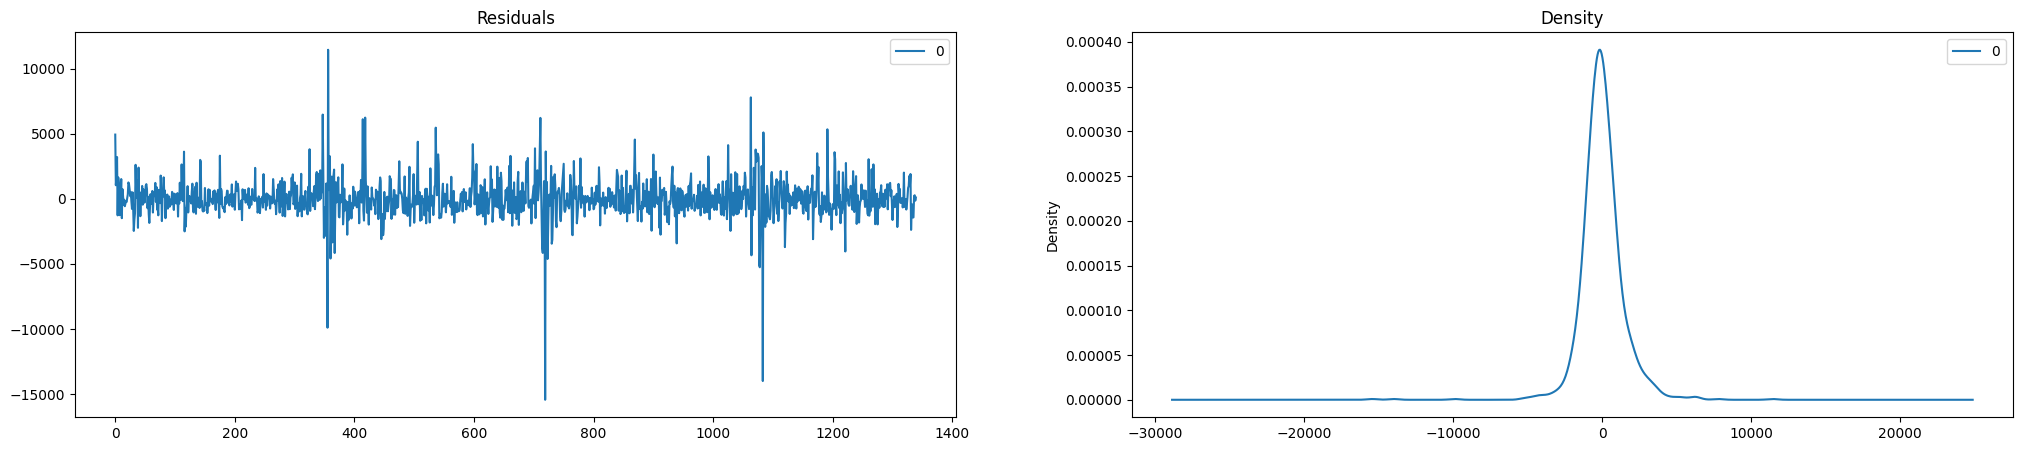

In [117]:
residuals = pd.DataFrame(sarimax_fit_s.resid)
fig, ax = plt.subplots(1,2, figsize=(25,5))
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

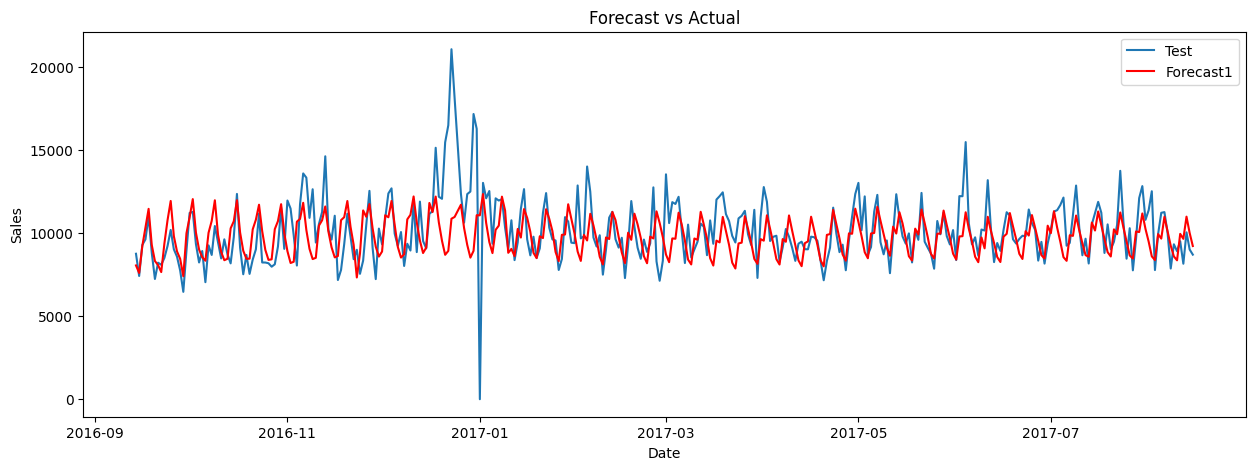

In [118]:
test_indexed = test.set_index('date')
forecast1 = sarimax_fit_s.predict(start=len(train), end=len(train)+len(test)-1, exog=test_indexed[['onpromotion_lag9', 'dcoilwtico','sales_ma7']])
forecast1.index = test_indexed.index

plt.figure(figsize=(15,5))
plt.title('Forecast vs Actual')
plt.plot(test_indexed['sales'], label='Test')
plt.plot(forecast1, label='Forecast1', color='r')
plt.legend()
plt.xlabel('Date') # Add x-axis label for clarity
plt.ylabel('Sales') # Add y-axis label for clarity
plt.show()

In [122]:
# Forecast for the test set
forecast_test = sarimax_fit_s.forecast(steps=len(test), exog=test[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']])

# Calculate metrics for the test set
wape_sarimax_test = (np.sum(np.abs(test['sales'] - forecast_test)) / np.sum(np.abs(test['sales']))) * 100
mae_sarimax_test = mean_absolute_error(test['sales'], forecast_test)
mse_sarimax_test = mean_squared_error(test['sales'], forecast_test)
rmse_sarimax_test = np.sqrt(mse_sarimax_test)

# Predict on the training data for WAPE calculation
forecast_train = sarimax_fit_s.predict(start=0, end=len(train)-1, exog=train[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']])

# Calculate metrics for the training set
wape_sarimax_train = (np.sum(np.abs(train['sales'] - forecast_train)) / np.sum(np.abs(train['sales']))) * 100
mae_sarimax_train = mean_absolute_error(train['sales'], forecast_train)
mse_sarimax_train = mean_squared_error(train['sales'], forecast_train)
rmse_sarimax_train = np.sqrt(mse_sarimax_train)

print(f"SARIMAX (sarimax_fit) WAPE on Test Set: {wape_sarimax_test:.2f}%")
print(f"SARIMAX (sarimax_fit) MAE on Test Set: {mae_sarimax_test:.2f}")
print(f"SARIMAX (sarimax_fit) MSE on Test Set: {mse_sarimax_test:.2f}")
print(f"SARIMAX (sarimax_fit) RMSE on Test Set: {rmse_sarimax_test:.2f}")

print(f"\nSARIMAX (sarimax_fit) WAPE on Train Set: {wape_sarimax_train:.2f}%")
print(f"SARIMAX (sarimax_fit) MAE on Train Set: {mae_sarimax_train:.2f}")
print(f"SARIMAX (sarimax_fit) MSE on Train Set: {mse_sarimax_train:.2f}")
print(f"SARIMAX (sarimax_fit) RMSE on Train Set: {rmse_sarimax_train:.2f}")

print(f"\nSARIMAX (sarimax_fit) AIC: {sarimax_fit.aic:.2f}")
print(f"SARIMAX (sarimax_fit) BIC: {sarimax_fit.bic:.2f}")


SARIMAX (sarimax_fit) WAPE on Test Set: 12.38%
SARIMAX (sarimax_fit) MAE on Test Set: 1253.62
SARIMAX (sarimax_fit) MSE on Test Set: 3419866.87
SARIMAX (sarimax_fit) RMSE on Test Set: 1849.29

SARIMAX (sarimax_fit) WAPE on Train Set: 10.55%
SARIMAX (sarimax_fit) MAE on Train Set: 955.37
SARIMAX (sarimax_fit) MSE on Train Set: 2182450.95
SARIMAX (sarimax_fit) RMSE on Train Set: 1477.31

SARIMAX (sarimax_fit) AIC: 23413.48
SARIMAX (sarimax_fit) BIC: 23460.29



Generating 30-Day Future Forecast...

Future Exogenous Variables (first 5 days):
            onpromotion_lag9  dcoilwtico    sales_ma7
2017-08-16             129.0       47.57  8975.597984
2017-08-17             107.0       47.57  8975.597984
2017-08-18             301.0       47.57  8975.597984
2017-08-19             125.0       47.57  8975.597984
2017-08-20             263.0       47.57  8975.597984

30-Day Forecast Preview:
date
2017-08-16     8739.667187
2017-08-17     7602.270467
2017-08-18     9606.219499
2017-08-19    10451.889592
2017-08-20    11300.355230
2017-08-21     9428.327298
2017-08-22     8616.692543


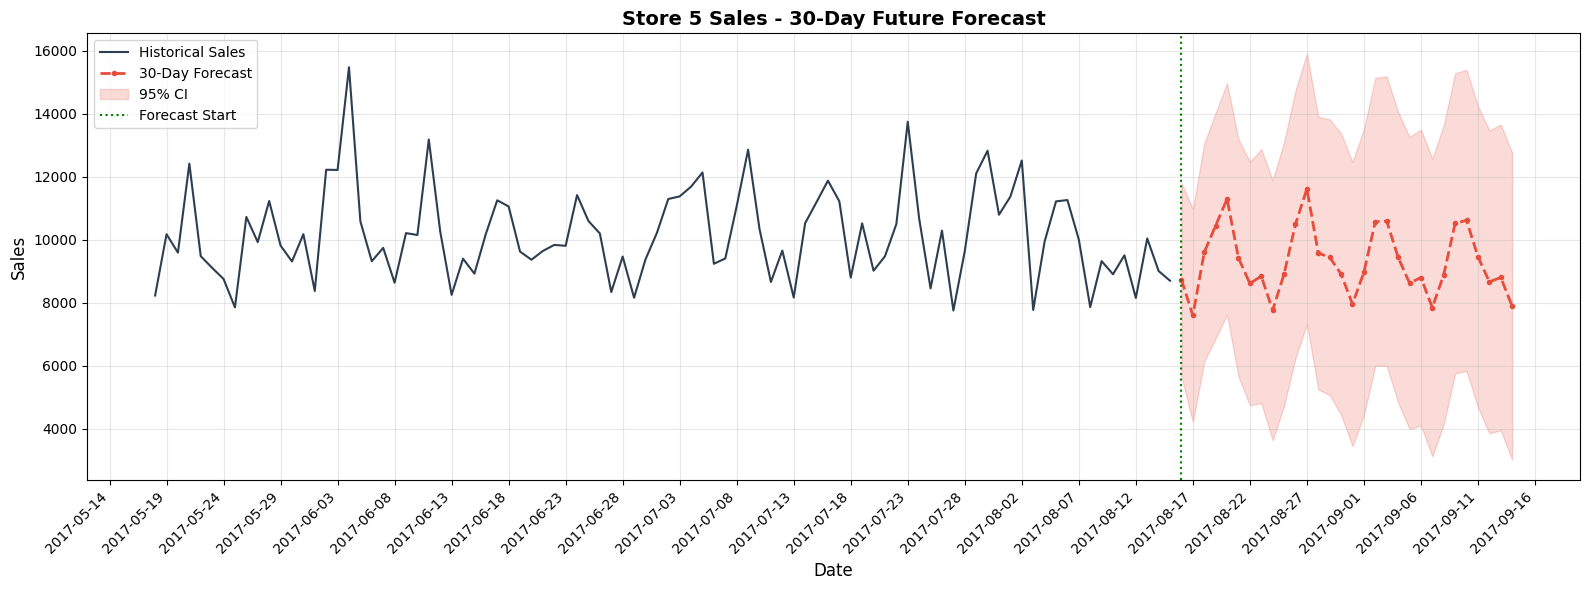


30-Day future forecast plot generated.


In [ ]:
print("\nGenerating 30-Day Future Forecast...")

# Define forecast parameters
forecast_start_date = data['date'].iloc[-1] + pd.Timedelta(days=1) # Start from day after last historical data
forecast_days_30 = 30
future_dates_30 = pd.date_range(start=forecast_start_date, periods=forecast_days_30, freq='D')

# Prepare future exogenous variables for 30 days
future_exog_30 = pd.DataFrame(index=future_dates_30)

# --- sales_ma7 ---
# Use last known MA7 as a constant estimate for future
last_known_ma7_full = data['sales_ma7'].dropna().iloc[-1]
future_exog_30['sales_ma7'] = last_known_ma7_full

# --- onpromotion_lag9 ---
# For the first 9 days of the forecast, we can use actual historical `onpromotion` values shifted.
# After that, we'll use the historical average of `onpromotion` as an estimate for future `onpromotion`.
# This means `onpromotion_lag9` will be based on `onpromotion` from `t-9` days.

# Get last known onpromotion values from historical data (to calculate lag for early forecast days)
last_onpromotion_values = data['onpromotion'].iloc[-9:].values
avg_onpromotion_historical = data['onpromotion'].mean()

# Create future 'onpromotion' values (assuming average after known lags)
future_onpromotion_raw = np.concatenate([
    last_onpromotion_values, # These are actual onpromotion values for the days preceding the forecast start
    np.full(forecast_days_30 - len(last_onpromotion_values), avg_onpromotion_historical) # Fill the rest with average
])

# Ensure `future_onpromotion_raw` has enough values for 30 days, adjusting if necessary
if len(future_onpromotion_raw) < forecast_days_30:
    future_onpromotion_raw = np.concatenate([
        future_onpromotion_raw,
        np.full(forecast_days_30 - len(future_onpromotion_raw), avg_onpromotion_historical)
    ])

# Create onpromotion_lag9 for future_exog_30. This means for day T in forecast, use onpromotion from T-9.
# Since future_onpromotion_raw is for future days, we shift it to get the lag.
# For the first 9 days of forecast, onpromotion_lag9 will come from the last 9 historical onpromotion values.
# For subsequent days, it will come from the assumed future_onpromotion_raw.

# Pad historical onpromotion to get enough values for the lag calculation
padded_onpromotion = pd.concat([pd.Series(data['onpromotion']), pd.Series(future_onpromotion_raw, index=future_dates_30)]) # Use pd.concat instead of append
# Then, calculate the lag9 on this padded series for the future_dates_30 index
future_exog_30['onpromotion_lag9'] = padded_onpromotion.shift(9).loc[future_dates_30].fillna(avg_onpromotion_historical) # Fill NaNs (if any due to short history) with average

# --- dcoilwtico ---
# Use last known oil price as a constant estimate for future
last_oil_price_full = data['dcoilwtico'].dropna().iloc[-1]
future_exog_30['dcoilwtico'] = last_oil_price_full

# Ensure order of exog variables matches training
future_exog_30 = future_exog_30[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']]

print("\nFuture Exogenous Variables (first 5 days):")
print(future_exog_30.head())

# Get forecast using sarimax_fit_s
future_forecast_obj_30 = sarimax_fit_s.get_forecast(
    steps=forecast_days_30,
    exog=future_exog_30
)

# Extract mean and confidence intervals
forecast_mean_30 = future_forecast_obj_30.predicted_mean
forecast_ci_30 = future_forecast_obj_30.conf_int(alpha=0.05) # 95% CI

# Create a DataFrame for the forecast results
df_forecast_30 = pd.DataFrame({
    'date': future_dates_30,
    'forecast_sales': forecast_mean_30.values,
    'lower_95ci': forecast_ci_30.iloc[:, 0].values,
    'upper_95ci': forecast_ci_30.iloc[:, 1].values
})
df_forecast_30.set_index('date', inplace=True)

print("\n30-Day Forecast Preview:")
print(df_forecast_30['forecast_sales'].head(7).to_string())

# Visualization
fig, ax = plt.subplots(figsize=(16, 6))

# Historical data (last 90 days from the 'data' DataFrame)
# Ensure 'date' is the index for plotting historical data
historical_plot_data = data.set_index('date')['sales']
recent_data = historical_plot_data.iloc[-90:] # Last 90 days of historical data

ax.plot(recent_data.index, recent_data, label='Historical Sales',
        color='#2c3e50', linewidth=1.5)

# Future forecast
ax.plot(df_forecast_30.index, df_forecast_30['forecast_sales'],
        label='30-Day Forecast', color='#e74c3c', linestyle='--',
        linewidth=2, marker='o', markersize=3)

# Confidence interval
ax.fill_between(df_forecast_30.index,
                df_forecast_30['lower_95ci'],
                df_forecast_30['upper_95ci'],
                color='#e74c3c', alpha=0.2, label='95% CI')

# Add a vertical line at the forecast start
ax.axvline(x=forecast_start_date, color='green', linestyle=':', linewidth=1.5, label='Forecast Start')

ax.set_title('Store 5 Sales - 30-Day Future Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n30-Day future forecast plot generated.")

## LSTM

### LSTM Training

In [ ]:
# Univariate
# Sales  ~ Sales (Data Lookback)

# Mulivariate
# Sales Data ~ Features
# Sales  ~ On Promotion, Week, Day, Years, IsHoliday

In [ ]:
import time

# Import min-max scaling function
from sklearn.preprocessing import MinMaxScaler

# Import keras lstm model
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Bidirectional, GRU, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

# Metrics
from sklearn import metrics
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
data_p = data
data_p

,date,sales,onpromotion,dcoilwtico,onpromotion_lag9,sales_lag7,sales_ma7
0,2013-01-10,5950.81402,0,93.81,0.0,7770.968000,7586.818289
1,2013-01-11,6379.97300,0,93.60,0.0,7347.641991,7326.796292
2,2013-01-12,6935.20600,0,93.60,0.0,8192.598000,7188.557864
3,2013-01-13,9284.70298,0,93.60,0.0,10843.232030,7008.930436
4,2013-01-14,6090.49100,0,94.27,0.0,6468.321000,6786.283429
...,...,...,...,...,...,...,...
1670,2017-08-11,9510.87100,263,48.81,322.0,9944.972000,9792.568999
1671,2017-08-12,8157.07000,116,48.81,104.0,11221.937000,9730.554570
1672,2017-08-13,10044.82100,124,48.81,260.0,11264.564000,9292.716427
1673,2017-08-14,9011.57490,118,47.59,129.0,10011.661000,9118.467427


In [ ]:
# Susun ulang kolom — sales dipindah ke posisi terakhir
data_lstm = data_p[['date','onpromotion', 'dcoilwtico', 'onpromotion_lag9',
                     'sales_lag7', 'sales_ma7', 'sales']].copy()

print(data_lstm.columns.tolist())
print(data_lstm.shape)
data_lstm.head()

['date', 'onpromotion', 'dcoilwtico', 'onpromotion_lag9', 'sales_lag7', 'sales_ma7', 'sales']
(1675, 7)


,date,onpromotion,dcoilwtico,onpromotion_lag9,sales_lag7,sales_ma7,sales
0,2013-01-10,0,93.81,0.0,7770.968000,7586.818289,5950.81402
1,2013-01-11,0,93.60,0.0,7347.641991,7326.796292,6379.97300
2,2013-01-12,0,93.60,0.0,8192.598000,7188.557864,6935.20600
3,2013-01-13,0,93.60,0.0,10843.232030,7008.930436,9284.70298
4,2013-01-14,0,94.27,0.0,6468.321000,6786.283429,6090.49100


In [ ]:
data_lstm = data_lstm.drop('sales_lag7', axis=1)
print(data_lstm.columns.tolist())
print(data_lstm.shape)
data_lstm.head()

['date', 'onpromotion', 'dcoilwtico', 'onpromotion_lag9', 'sales_ma7', 'sales']
(1675, 6)


,date,onpromotion,dcoilwtico,onpromotion_lag9,sales_ma7,sales
0,2013-01-10,0,93.81,0.0,7586.818289,5950.81402
1,2013-01-11,0,93.60,0.0,7326.796292,6379.97300
2,2013-01-12,0,93.60,0.0,7188.557864,6935.20600
3,2013-01-13,0,93.60,0.0,7008.930436,9284.70298
4,2013-01-14,0,94.27,0.0,6786.283429,6090.49100


In [ ]:
data_lstm.isnull().sum()
data_lstm.dtypes

,0
date,datetime64[ns]
onpromotion,int64
dcoilwtico,float64
onpromotion_lag9,float64
sales_ma7,float64
sales,float64


In [ ]:
for column in data_lstm.columns:
    zero_count = (data_p[column] == 0).sum()
    print(f"Feature '{column}': {zero_count} zero values")

Feature 'date': 0 zero values
Feature 'onpromotion': 537 zero values
Feature 'dcoilwtico': 0 zero values
Feature 'onpromotion_lag9': 546 zero values
Feature 'sales_ma7': 0 zero values
Feature 'sales': 4 zero values


In [ ]:
# Lihat semua kolom pada baris sales = 0
print(data_lstm[data_lstm['sales'] == 0].to_string())


           date  onpromotion  dcoilwtico  onpromotion_lag9     sales_ma7  sales
355  2014-01-01            0       98.17               0.0  11577.679434    0.0
719  2015-01-01            0       53.45              45.0  16672.811283    0.0
1083 2016-01-01            0       37.13              54.0  14673.028009    0.0
1448 2017-01-01            0       53.75             322.0  14200.402719    0.0


In [ ]:
# Split data
# Scalling

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()
x = data_lstm[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']].copy()
y = data_lstm['sales'].copy()

x[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']] = x_scaler.fit_transform(x)
y = y_scaler.fit_transform(y.values.reshape(-1, 1))

In [ ]:
def load_data(X, seq_len, train_size=0.8):
    amount_of_features = X.shape[1]
    X_mat = X.values
    sequence_length = seq_len + 1
    data = []

    for index in range(len(X_mat) - sequence_length):
        data.append(X_mat[index: index + sequence_length])

    data = np.array(data)
    train_split = int(round(train_size * data.shape[0]))
    train_data = data[:train_split, :]

    x_train = train_data[:, :-1]
    y_train = train_data[:, -1][:,-1]

    x_test = data[train_split:, :-1]
    y_test = data[train_split:, -1][:,-1]

    x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], amount_of_features))
    x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], amount_of_features))

    return x_train, y_train, x_test, y_test

window = 7
x['sales'] = y
X_train, y_train, X_test, y_test = load_data(x, window)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(1334, 7, 4) (1334,) (333, 7, 4) (333,)


## Single LSTM

In [ ]:
#LSTM architecture
model1 = Sequential()
# First LSTM layer with Dropout regularisation
model1.add(LSTM(units=50, input_shape=(window,4)))
model1.add(Dropout(0.2))

# The output layer
model1.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model1.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))


# Compiling the RNN
model1.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history1=model1.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1)
print ('compilation time : ', time.time() - start)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0684 - val_loss: 0.0134
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0102 - val_loss: 0.0071
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0086 - val_loss: 0.0052
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0086 - val_loss: 0.0058
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0084 - val_loss: 0.0048
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0080 - val_loss: 0.0056
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0081 - val_loss: 0.0047
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0080 - val_loss: 0.0046
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0081 - val_loss: 0.0056
Epoch 12/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.

<Axes: >

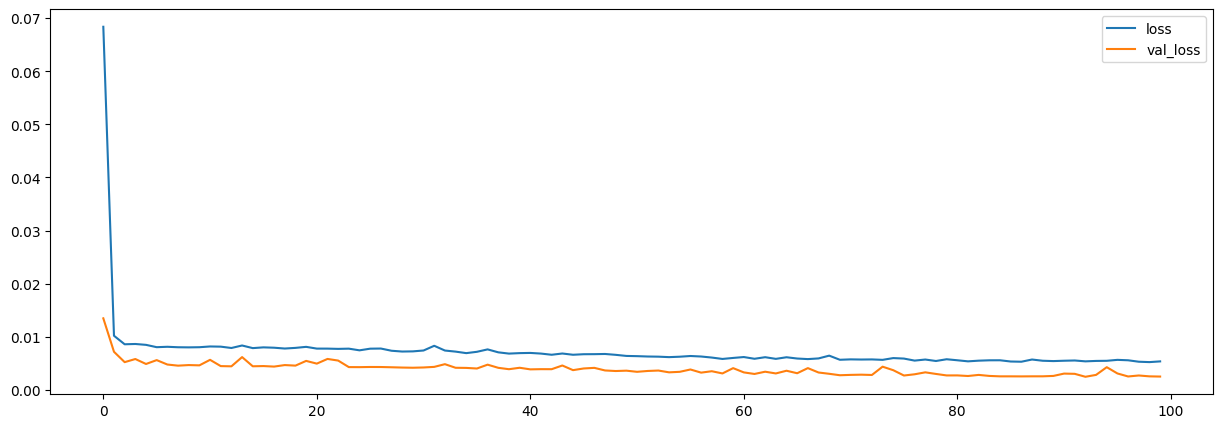

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history1.history)
losses.plot()

In [ ]:
trainPredict = model1.predict(X_train)
testPredict = model1.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(testPredict.shape[0], 1) # Corrected reshape to match testPredict size
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(testY.shape[1], 1) # Corrected reshape to match testY size
print(plot_actual.shape)
print(plot_predicted.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
(333, 1)
(333, 1)


In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 1586.71 RMSE
Test Score: 1766.65 RMSE


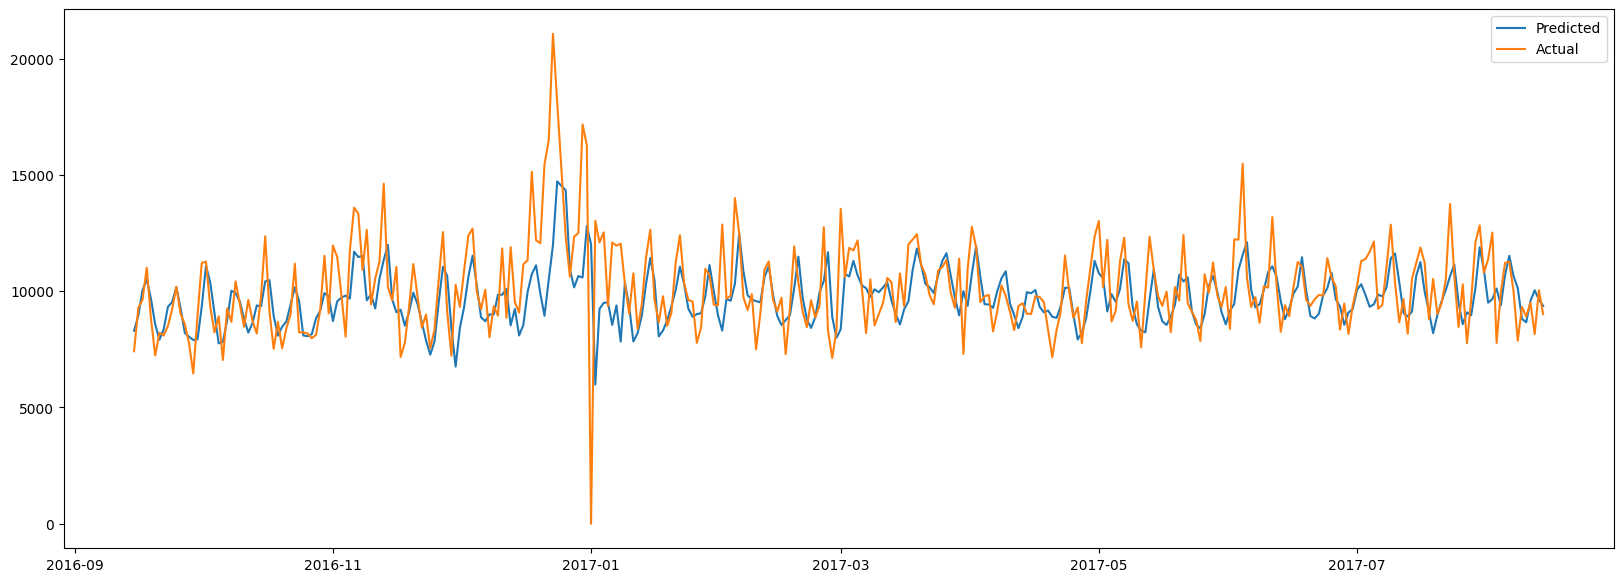

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(20,7))


plot_x = data_lstm['date'].iloc[start_index_for_plot_x : start_index_for_plot_x + len(plot_predicted)]

plt.plot(plot_x, pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(plot_x, pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 2 - Stack LSTM using Dropout

In [ ]:
#LSTM architecture
model2 = Sequential()
# First LSTM layer with Dropout regularisation
model2.add(LSTM(units=50, input_shape=(window,4),return_sequences=True))
model2.add(Dropout(0.2))
# Second LSTM layer
model2.add(LSTM(units=50))
model2.add(Dropout(0.2))

# The output layer
model2.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model2.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compiling the RNN
model2.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history2=model2.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1,callbacks=callbacks_list)
print ('compilation time : ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0531 - val_loss: 0.0044
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0138 - val_loss: 0.0045
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.0106 - val_loss: 0.0058
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0103 - val_loss: 0.0043
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0102 - val_loss: 0.0043
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0103 - val_loss: 0.0090
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0104 - val_loss: 0.0044
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0096 - val_loss: 0.0047
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0093 - val_loss: 0.0051
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0092 - val_loss: 0.0053
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0090 - val_loss: 0.0052
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0

<Axes: >

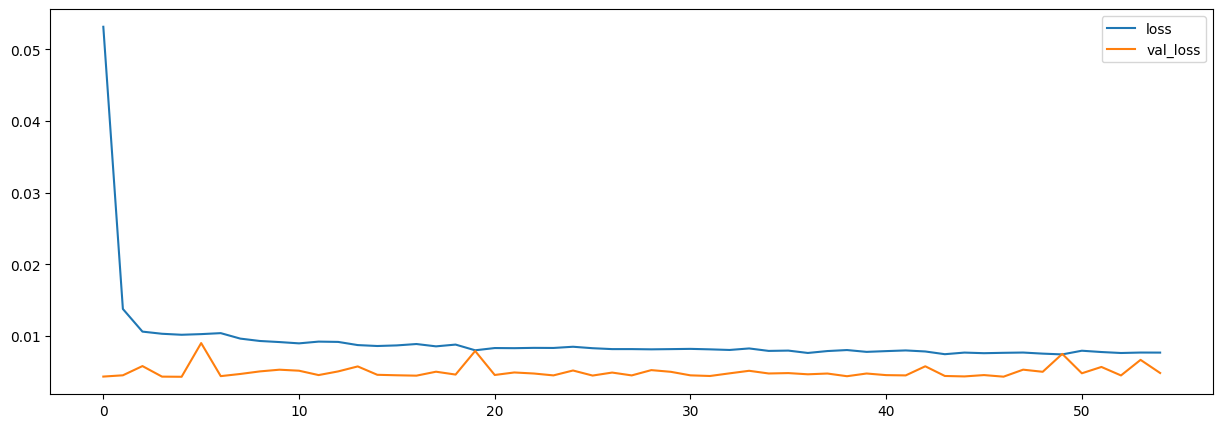

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history2.history)
losses.plot()

In [ ]:
trainPredict = model2.predict(X_train)
testPredict = model2.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(testPredict.shape[0], 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(testY.shape[1], 1)
print(plot_actual.shape)
print(plot_predicted.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
(330, 1)
(330, 1)


In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 1889.86 RMSE
Test Score: 1913.09 RMSE


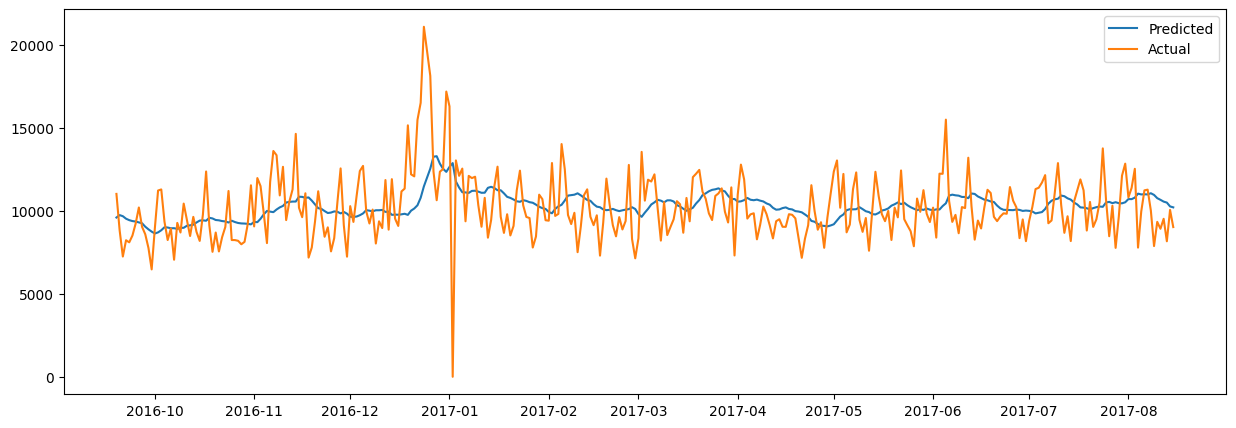

In [ ]:
plot_x = test['date'].iloc[-len(plot_predicted):]
plt.plot(plot_x, pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(plot_x, pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 3 - Bidirectional LSTM

In [ ]:
# Stack LSTM architecture
model3 = Sequential()
# Bidirectional LSTM layer with Dropout regularisation
model3.add(Bidirectional(LSTM(units=50), input_shape=(window,4)))
model3.add(Dropout(0.2))
# The output layer
model3.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model3.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compiling the RNN
model3.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history3=model3.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1,callbacks=callbacks_list)
print ('compilation time : ', time.time() - start)

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.0520 - val_loss: 0.0048
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0101 - val_loss: 0.0069
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0095 - val_loss: 0.0087
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0093 - val_loss: 0.0057
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0091 - val_loss: 0.0042
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0089 - val_loss: 0.0051
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0087 - val_loss: 0.0042
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0088 - val_loss: 0.0042
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0083 - val_loss: 0.0042
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0083 - val_loss: 0.0041
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0085 - val_loss: 0.0046
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0

<Axes: >

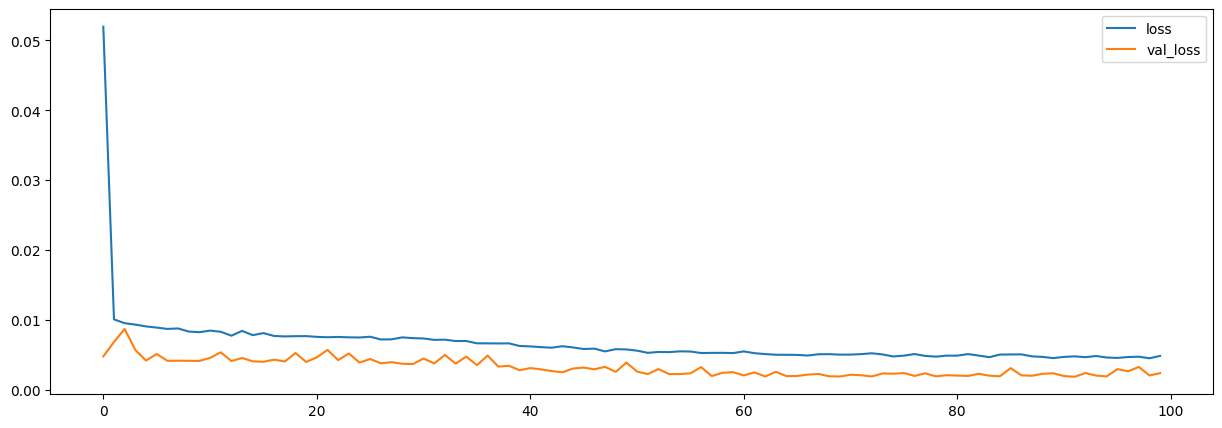

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history3.history)
losses.plot()

In [ ]:
trainPredict = model3.predict(X_train)
testPredict = model3.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(testPredict.shape[0], 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(testY.shape[1], 1)
print(plot_actual.shape)
print(plot_predicted.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
(330, 1)
(330, 1)


In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 1479.68 RMSE
Test Score: 1689.05 RMSE


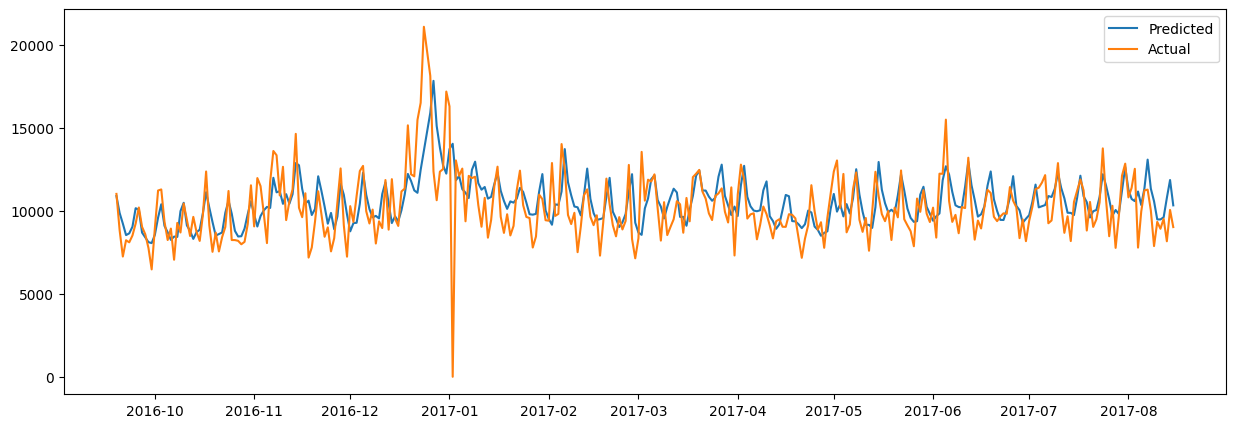

In [ ]:
plot_x = test['date'].iloc[-len(plot_predicted):]
plt.plot(plot_x, pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(plot_x, pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 4 - GRU

In [ ]:
# Stack LSTM architecture
model4 = Sequential()
# GRU layer with Dropout regularisation
model4.add(GRU(units=50, input_shape=(window,4)))
model4.add(Dropout(0.2))

# The output layer
model4.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model4.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))

earlystop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=50)
callbacks_list = [earlystop]

# Compiling the RNN
model4.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history4=model4.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1,callbacks=callbacks_list)
print ('compilation time : ', time.time() - start)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0629 - val_loss: 0.0141
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0101 - val_loss: 0.0059
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0083 - val_loss: 0.0051
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0082 - val_loss: 0.0047
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0081 - val_loss: 0.0050
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0083 - val_loss: 0.0054
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0080 - val_loss: 0.0055
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0078 - val_loss: 0.0043
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0073 - val_loss: 0.0041
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0078 - val_loss: 0.0046
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0076 - val_loss: 0.0040
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

<Axes: >

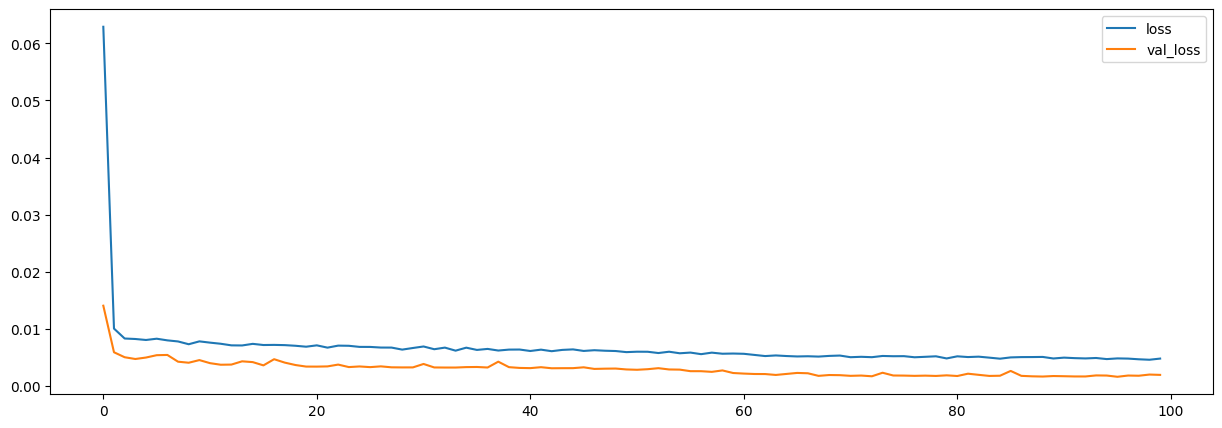

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history4.history)
losses.plot()

In [ ]:
trainPredict = model4.predict(X_train)
testPredict = model4.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(testPredict.shape[0], 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(testY.shape[1], 1)
print(plot_actual.shape)
print(plot_predicted.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
(330, 1)
(330, 1)


In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 1487.71 RMSE
Test Score: 1564.33 RMSE


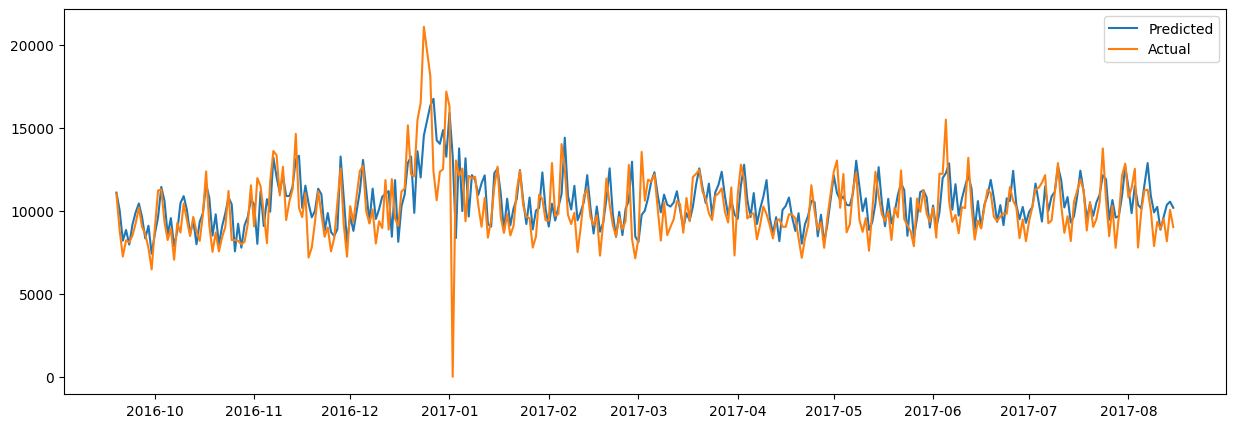

In [ ]:
plot_x = test['date'].iloc[-len(plot_predicted):]
plt.plot(plot_x, pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(plot_x, pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

# Model 5 - LSTM using BatchNormalization and Regularization L1 & L2

In [ ]:
# LSTM using BatchNormalization and Regularization (L1 and L2)
#LSTM architecture
model5 = Sequential()
# First LSTM layer with Dropout regularisation
model5.add(LSTM(units=50, input_shape=(window,4),kernel_regularizer='l2'))
model5.add(BatchNormalization())
model5.add(Dropout(0.2))

# The output layer
model5.add(Dense(units=50, kernel_initializer='uniform', activation='tanh'))
model5.add(Dense(units=1, kernel_initializer='uniform', activation='linear'))


# Compiling the RNN
model5.compile(optimizer='adam',loss='mean_squared_error')
# Fitting to the training set
start = time.time()
history5=model5.fit(X_train,y_train,epochs=100,batch_size=35, validation_split=0.05, verbose=1)
print ('compilation time : ', time.time() - start)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1859 - val_loss: 0.1089
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0580 - val_loss: 0.0255
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0274 - val_loss: 0.0166
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0188 - val_loss: 0.0116
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0146 - val_loss: 0.0089
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0119 - val_loss: 0.0086
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0109 - val_loss: 0.0069
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0097 - val_loss: 0.0065
Epoch 9/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0097 - val_loss: 0.0056
Epoch 10/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0092 - val_loss: 0.0057
Epoch 11/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0086 - val_loss: 0.0057
Epoch 12/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step

<Axes: >

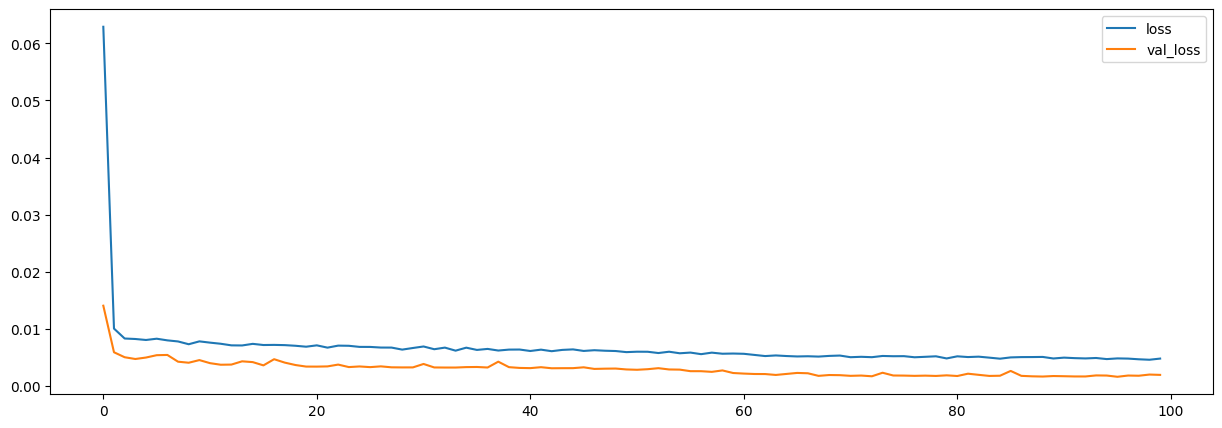

In [ ]:
%matplotlib inline
losses = pd.DataFrame(history4.history)
losses.plot()

In [ ]:
trainPredict = model5.predict(X_train)
testPredict = model5.predict(X_test)

trainPredict = y_scaler.inverse_transform(trainPredict)
trainY = y_scaler.inverse_transform([y_train])
testPredict = y_scaler.inverse_transform(testPredict)
testY = y_scaler.inverse_transform([y_test])

plot_predicted = testPredict.copy()
plot_predicted = plot_predicted.reshape(testPredict.shape[0], 1)
plot_actual = testY.copy()
plot_actual = plot_actual.reshape(testY.shape[1], 1)
print(plot_actual.shape)
print(plot_predicted.shape)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
(330, 1)
(330, 1)


In [ ]:
trainScore = mean_squared_error(trainY[0], trainPredict[:,0]) ** .5
print('Train Score: %.2f RMSE' % (trainScore))
testScore = mean_squared_error(testY[0], testPredict[:,0]) ** .5
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 3243.04 RMSE
Test Score: 3351.61 RMSE


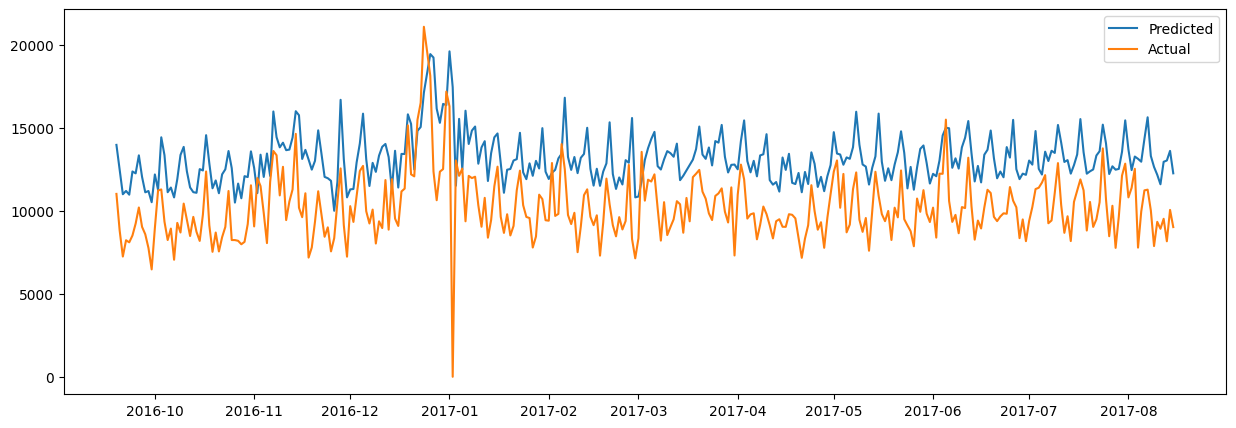

In [ ]:
plot_x = test['date'].iloc[-len(plot_predicted):]
plt.plot(plot_x, pd.DataFrame(plot_predicted), label='Predicted')
plt.plot(plot_x, pd.DataFrame(plot_actual), label='Actual')
plt.legend(loc='best')
plt.show()

### Evaluation

# Comparison Model

In [ ]:
model = [model1, model2, model3, model4, model5]
history = [history1, history2, history3, history4, history5]
trainScore = []
testScore = []

for i in range(5):
    trainPredict = model[i].predict(X_train)
    testPredict = model[i].predict(X_test)

    trainPredict = y_scaler.inverse_transform(trainPredict)
    trainY = y_scaler.inverse_transform([y_train])
    testPredict = y_scaler.inverse_transform(testPredict)
    testY = y_scaler.inverse_transform([y_test])

    trainScore.append(mean_squared_error(trainY[0], trainPredict[:,0]) ** .5)
    testScore.append(mean_squared_error(testY[0], testPredict[:,0]) ** .5)

    print('Model', i+1)
    print('Train Score: %.2f RMSE' % (trainScore[i]))
    print('Test Score: %.2f RMSE' % (testScore[i]))
    print('\n')


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Model 1
Train Score: 1635.98 RMSE
Test Score: 1678.30 RMSE


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Model 2
Train Score: 1889.86 RMSE
Test Score: 1913.09 RMSE


42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Model 3
Train Score: 1479.68 RMSE
Test Score: 1689.05 RMSE


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Model 4
Train Score: 1487.71 RMSE
Test Score: 1564.33 RMSE


42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Model 5
Train Score: 3243.04 RMSE
Test Score: 3351.61 RMSE




In [ ]:
# Make trainscore and testscore to dataframe
name_of_model = ['LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'GRU', 'LSTM with BatchNormalization and Regularization']
df_score = pd.DataFrame({'Model':name_of_model,'Train Score': trainScore, 'Test Score': testScore})
df_score

,Model,Train Score,Test Score
0,LSTM,1635.983361,1678.298576
1,Stacked LSTM,1889.857919,1913.093550
2,Bidirectional LSTM,1479.682423,1689.054119
3,GRU,1487.714311,1564.331614
4,LSTM with BatchNormalization and Regularization,3243.035312,3351.614167


Total y_test             : 330
Exclude tanggal 1 Jan    : 1
Data setelah filter      : 329

  LSTM
  WAPE : 11.8080%
  RMSE : 1680.5520
  MAE  : 1197.6086

  Stacked LSTM
  WAPE : 13.8473%
  RMSE : 1913.2078
  MAE  : 1404.4342

  Bidirectional LSTM
  WAPE : 11.6701%
  RMSE : 1690.6464
  MAE  : 1183.6218

  GRU
  WAPE : 10.6880%
  RMSE : 1566.7059
  MAE  : 1084.0074

  LSTM with BatchNorm & Regularization
  WAPE : 30.0010%
  RMSE : 3354.3547
  MAE  : 3042.7953


📋 TABEL KOMPARASI 5 MODEL (exclude 1 Januari)
                                       WAPE %       RMSE        MAE
Model                                                              
LSTM                                  11.8080  1680.5520  1197.6086
Stacked LSTM                          13.8473  1913.2078  1404.4342
Bidirectional LSTM                    11.6701  1690.6464  1183.6218
GRU                                   10.6880  1566.7059  1084.0074
LSTM with BatchNorm & Regularization  30.0010  3354.3547  3042.7953

🏆 MODEL TER

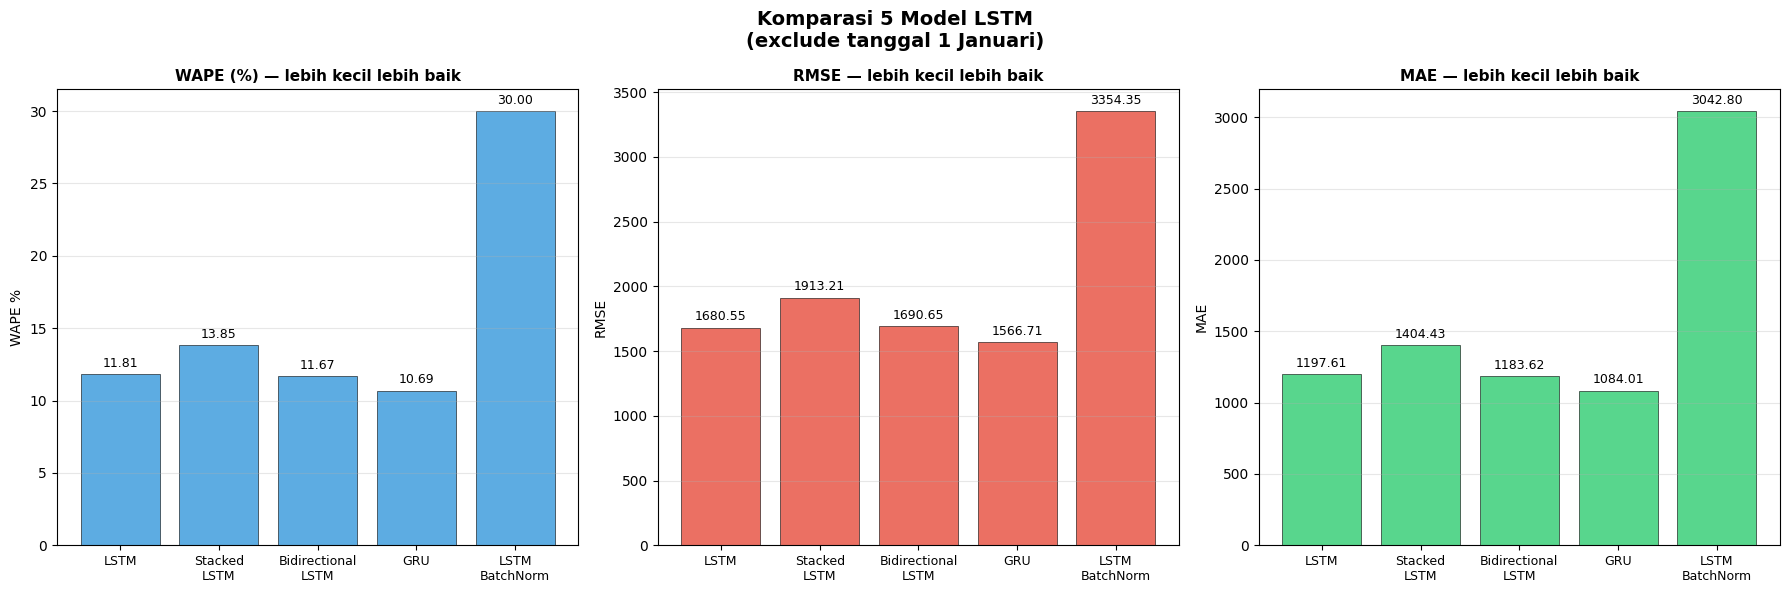


Plot komparasi disimpan ke: komparasi_5model_lstm.png


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# FUNGSI WAPE
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


# REKONSTRUKSI TANGGAL y_test & FILTER 1 JANUARI

test_dates = data_lstm.index[-(len(y_test) + window):-window]
mask_jan1  = ~((test_dates.month == 1) & (test_dates.day == 1))

print(f"Total y_test             : {len(y_test)}")
print(f"Exclude tanggal 1 Jan    : {(~mask_jan1).sum()}")
print(f"Data setelah filter      : {mask_jan1.sum()}")


# LOOP EVALUASI 5 MODEL

models      = [model1, model2, model3, model4, model5]
model_names = [
    'LSTM',
    'Stacked LSTM',
    'Bidirectional LSTM',
    'GRU',
    'LSTM with BatchNorm & Regularization'
]

results = []

for name, model in zip(model_names, models):
    # Prediksi & inverse transform
    y_pred_scaled = model.predict(X_test, verbose=0)
    y_pred_all    = y_scaler.inverse_transform(y_pred_scaled).flatten()
    y_true_all    = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # Filter 1 Januari
    y_pred_f = y_pred_all[mask_jan1]
    y_true_f = y_true_all[mask_jan1]

    # Hitung metrik
    wape_val = wape(y_true_f, y_pred_f)
    rmse     = np.sqrt(mean_squared_error(y_true_f, y_pred_f))
    mae      = mean_absolute_error(y_true_f, y_pred_f)

    results.append({
        'Model' : name,
        'WAPE %': round(wape_val, 4),
        'RMSE'  : round(rmse,     4),
        'MAE'   : round(mae,      4),
    })

    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  WAPE : {wape_val:.4f}%")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")


# TABEL KOMPARASI

df_results = pd.DataFrame(results).set_index('Model')

print("\n\n📋 TABEL KOMPARASI 5 MODEL (exclude 1 Januari)")
print("="*55)
print(df_results.to_string())
print("="*55)

print("\n🏆 MODEL TERBAIK PER METRIK:")
print(f"  WAPE terkecil : {df_results['WAPE %'].idxmin():<40} ({df_results['WAPE %'].min():.4f}%")
print(f"  RMSE terkecil : {df_results['RMSE'].idxmin():<40} ({df_results['RMSE'].min():.4f})")
print(f"  MAE  terkecil : {df_results['MAE'].idxmin():<40} ({df_results['MAE'].min():.4f})")


# VISUALISASI BAR CHART (3 metrik)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Komparasi 5 Model LSTM\n(exclude tanggal 1 Januari)',
             fontsize=14, fontweight='bold')

metrics     = ['WAPE %', 'RMSE', 'MAE']
titles      = ['WAPE (%) — lebih kecil lebih baik',
               'RMSE — lebih kecil lebih baik',
               'MAE — lebih kecil lebih baik']
colors      = ['#3498db', '#e74c3c', '#2ecc71']
short_names = ['LSTM', 'Stacked\nLSTM', 'Bidirectional\nLSTM', 'GRU', 'LSTM\nBatchNorm']

for ax, metric, title, color in zip(axes.flatten(), metrics, titles, colors):
    values = df_results[metric].values
    bars   = ax.bar(short_names, values, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)


    # Tambah nilai di atas bar
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig('komparasi_5model_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot komparasi disimpan ke: komparasi_5model_lstm.png")

In [ ]:
# Comparison Table : MAPE, RMSE, MAE,  (with exogenous variable)

# Forecasting The Best Model (Optional)

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2017-08-15 00:00:00

Generating 30-Day Future Forecast (LSTM model4)...
Future Exog (5 hari pertama):
              sales_ma7  onpromotion_lag9  dcoilwtico
2017-08-16  8975.597984             168.0       47.57
2017-08-17  8975.597984             157.0       47.57
2017-08-18  8975.597984             163.0       47.57
2017-08-19  8975.597984             134.0       47.57
2017-08-20  8975.597984             322.0       47.57

30-Day Forecast Preview:
2017-08-16     9645.397461
2017-08-17     8396.172852
2017-08-18     9390.197266
2017-08-19    10376.255859
2017-08-20    10344.181641
2017-08-21     9434.243164
2017-08-22     9728.619141
Freq: D


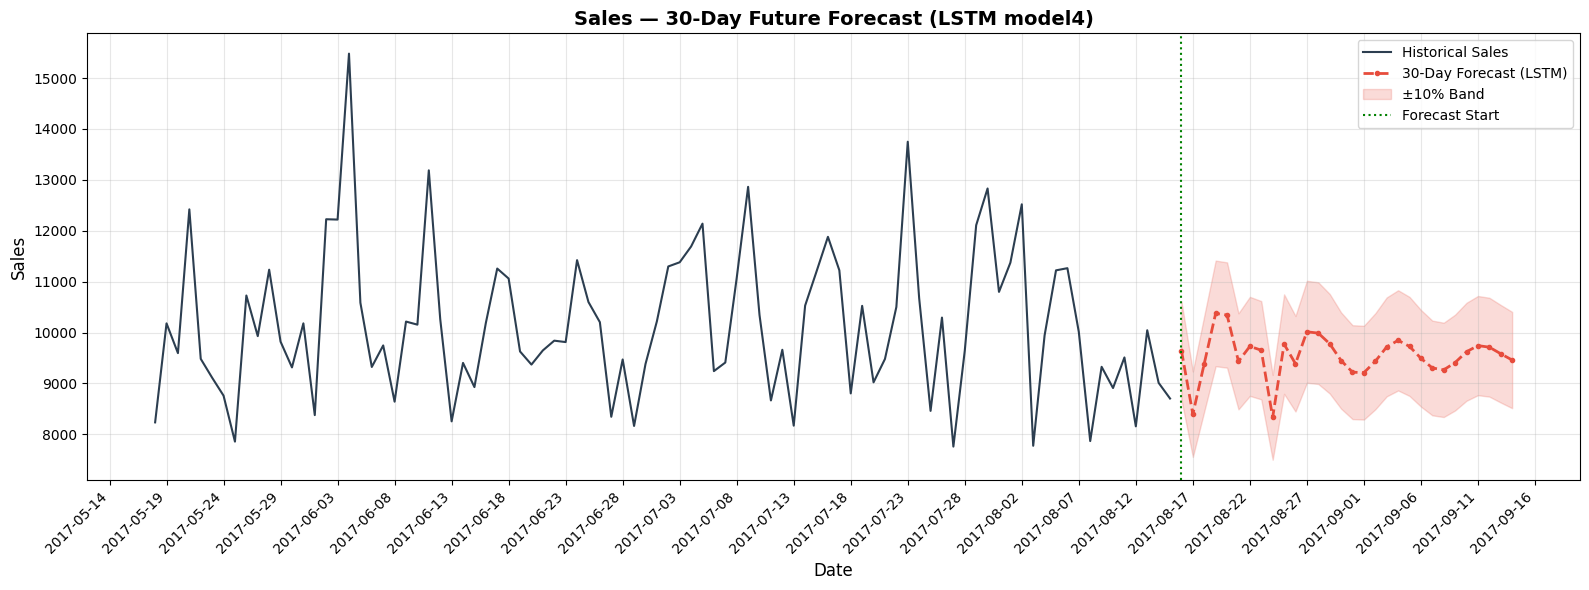


30-Day future forecast plot generated.


In [ ]:
# ============================================================
# FIX — Set 'date' sebagai index terlebih dahulu
# ============================================================
if 'date' in data_lstm.columns:
    data_lstm = data_lstm.set_index('date')
    data_lstm.index = pd.to_datetime(data_lstm.index)

# Cek index sekarang
print(type(data_lstm.index))        # harus DatetimeIndex
print(data_lstm.index[-1])          # harus tampil tanggal, misal 2017-08-15

print("\nGenerating 30-Day Future Forecast (LSTM model4)...")

# ============================================================
# STEP 1 — DEFINISIKAN TANGGAL FORECAST
# ============================================================
forecast_start_date = data_lstm.index[-1] + pd.Timedelta(days=1)
forecast_days_30    = 30
future_dates_30     = pd.date_range(start=forecast_start_date, periods=forecast_days_30, freq='D')

# ============================================================
# STEP 2 — SIAPKAN FUTURE EXOGENOUS VARIABLES
# ============================================================
future_exog_30 = pd.DataFrame(index=future_dates_30)

# --- sales_ma7 ---
last_known_ma7 = data_lstm['sales_ma7'].dropna().iloc[-1]
future_exog_30['sales_ma7'] = last_known_ma7

# --- onpromotion_lag9 ---
last_onpromotion_values      = data_lstm['onpromotion_lag9'].iloc[-9:].values
avg_onpromotion_historical   = data_lstm['onpromotion_lag9'].mean()

future_onpromotion_raw = np.concatenate([
    last_onpromotion_values,
    np.full(forecast_days_30 - len(last_onpromotion_values), avg_onpromotion_historical)
])
future_exog_30['onpromotion_lag9'] = future_onpromotion_raw[:forecast_days_30]

# --- dcoilwtico ---
last_oil_price = data_lstm['dcoilwtico'].dropna().iloc[-1]
future_exog_30['dcoilwtico'] = last_oil_price

print("Future Exog (5 hari pertama):")
print(future_exog_30.head())

# ============================================================
# STEP 3 — SCALE FUTURE EXOG (pakai x_scaler yang sudah fit)
# ============================================================
future_exog_scaled = x_scaler.transform(
    future_exog_30[['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']]
)
future_exog_scaled = pd.DataFrame(
    future_exog_scaled,
    columns=['onpromotion_lag9', 'dcoilwtico', 'sales_ma7'],
    index=future_dates_30
)

# ============================================================
# STEP 4 — SIAPKAN SEED WINDOW (22 hari terakhir dari data historis)
# ============================================================
# Ambil 22 hari terakhir dari data yang sudah di-scale
# x sudah berisi (onpromotion_lag9, dcoilwtico, sales_ma7, sales) yang ter-scale
last_window = x.values[-window:]  # shape: (22, 4)

# ============================================================
# STEP 5 — ROLLING FORECAST (1 hari per iterasi)
# ============================================================
forecast_scaled = []
current_window  = last_window.copy()  # shape: (22, 4)

for i in range(forecast_days_30):
    # Reshape ke (1, 22, 4) untuk input LSTM
    input_seq = current_window.reshape(1, window, 4)

    # Prediksi 1 langkah
    pred_scaled = model4.predict(input_seq, verbose=0)[0][0]
    forecast_scaled.append(pred_scaled)

    # Buat baris baru: gabungkan exog future + prediksi sales
    new_exog = future_exog_scaled.iloc[i][['onpromotion_lag9', 'dcoilwtico', 'sales_ma7']].values
    new_row  = np.append(new_exog, pred_scaled)  # shape: (4,)

    # Geser window: buang hari pertama, tambah hari baru
    current_window = np.vstack([current_window[1:], new_row])  # shape: (22, 4)

# ============================================================
# STEP 6 — INVERSE TRANSFORM HASIL FORECAST
# ============================================================
forecast_scaled_arr = np.array(forecast_scaled).reshape(-1, 1)
forecast_sales      = y_scaler.inverse_transform(forecast_scaled_arr).flatten()

# ============================================================
# STEP 7 — BUAT DATAFRAME HASIL
# ============================================================
df_forecast_30 = pd.DataFrame({
    'forecast_sales': forecast_sales
}, index=future_dates_30)

# Estimasi confidence interval ±10% (LSTM tidak punya CI bawaan)
df_forecast_30['lower_95ci'] = df_forecast_30['forecast_sales'] * 0.90
df_forecast_30['upper_95ci'] = df_forecast_30['forecast_sales'] * 1.10

print("\n30-Day Forecast Preview:")
print(df_forecast_30['forecast_sales'].head(7).to_string())

# ============================================================
# STEP 8 — VISUALISASI
# ============================================================
fig, ax = plt.subplots(figsize=(16, 6))

# Historical sales (90 hari terakhir)
recent_data = data_lstm['sales'].iloc[-90:]
ax.plot(recent_data.index, recent_data,
        label='Historical Sales', color='#2c3e50', linewidth=1.5)

# Forecast
ax.plot(df_forecast_30.index, df_forecast_30['forecast_sales'],
        label='30-Day Forecast (LSTM)', color='#e74c3c',
        linestyle='--', linewidth=2, marker='o', markersize=3)

# Confidence interval
ax.fill_between(df_forecast_30.index,
                df_forecast_30['lower_95ci'],
                df_forecast_30['upper_95ci'],
                color='#e74c3c', alpha=0.2, label='±10% Band')

# Garis pemisah
ax.axvline(x=forecast_start_date, color='green', linestyle=':',
           linewidth=1.5, label='Forecast Start')

ax.set_title('Sales — 30-Day Future Forecast (LSTM model4)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales', fontsize=12)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n30-Day future forecast plot generated.")